In [1]:
import scipy.io
import io

from data_loader import DataLoader

import numpy as np
from utils import *
from matplotlib import pyplot as plt
import numpy.random as rng
import pandas as pd

import os
import math

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
home_dir = os.path.abspath(os.path.curdir)
data_dir = os.path.join(home_dir, '..', 'Data')
ultralight = os.path.join(data_dir, 'GG-Dataset-Tulio-Ultralight')

print(os.path.abspath(home_dir))
print(os.path.abspath(data_dir))
print(os.path.abspath(ultralight))

/Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/URI-project
/Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/Data
/Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/Data/GG-Dataset-Tulio-Ultralight


In [3]:
def load_data(rats):
    return DataLoader(data_dir, 'Hpc', rats=[rats])
    
rats = ['Rat08', 'Rat09', 'Rat10', 'Rat11']
rat_id = 3
rat = rats[rat_id] 
area ='all'

#load data
data = load_data(rat)
spks = data.get_spk()
pos = data._get_pos()

/Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/URI-project/data_loader.py:592: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/Data/Rat11/Rat11-20150402/Rat11-20150402.puf.evt
  self.__warning_msg(path)
/Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/Data/Rat11/Rat11-20150318/Rat11-20150318-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])
/Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/madeliefvanmeggelen/Documents/Radboud/AI_year4/Thesis/codes/Data/Rat11/Rat11-20150315/Rat11-20150315-pos.csv
  self.__warning_msg(self.paths[rat][session]['positi

**Preprocessing functions**

In [10]:
def session_variable(session_idx):
    sessions_data = list(data.events[rat].keys())
    sessions_spks = list(spks[rat].keys()) 

    sessions = np.intersect1d(sessions_spks, sessions_data)
    sessions.sort()
    session = sessions[session_idx]

    session_neurons = spks[rat][session][area]
    neuron_ids = list(spks[rat][session][area].keys())
    n_neurons = len(neuron_ids)

    begin_run_i = int(list(data.events[rat][session]['cat']['data']).index('beginning run'))
    end_run_i = int(list(data.events[rat][session]['cat']['data']).index('end run'))

    begin_run_t = int(list(data.events[rat][session]['cat']['ts'])[begin_run_i])
    end_run_t = int(list(data.events[rat][session]['cat']['ts'])[end_run_i])
    
    return neuron_ids, n_neurons, session, session_neurons, begin_run_t, end_run_t

In [11]:
def position_variable(session):
    x = data.position[rat][session]['x']
    y = data.position[rat][session]['y']
    time_location = data.position[rat][session]['Time']

    # location_run_idx = [index for index, t in enumerate(time_location) if t > begin_run_t and t < end_run_t]

    # x_run = x[location_run_idx[0]:location_run_idx[-1]]
    # y_run = y[location_run_idx[0]:location_run_idx[-1]]
    run_indices = (time_location >= begin_run_t) & (time_location <= end_run_t)
    x_run = x[run_indices]
    y_run = y[run_indices]
    time_run = time_location[run_indices]

    # Find the puff events and location
    puff_events_ = data.events[rat][session]['puf']['ts']
    puff_events = []
    
    # Make sure the puff events are an int format (some sessions consist of strings)
    if isinstance(list(puff_events_)[0], str):
        for t in np.array(puff_events_):
            puff_events.append(float(t[:14]))
    else:
        puff_events = puff_events_

    # Filter puff events to run session
    puff_events = [t for t in puff_events if t > begin_run_t and t < end_run_t]
    
    
    puff_x_location = [x_run[np.absolute(time_location-i).argmin()] for i in puff_events]
    puff_y_location = [y_run[np.absolute(time_location-i).argmin()] for i in puff_events]

    # Find the mean of the puff location
    x_mean = np.mean(puff_x_location)

    return x, y, time_location, x_run, y_run, time_run, puff_events, puff_x_location, puff_y_location, x_mean

In [12]:
def preprocess_rewards(left_reward_ts_, right_reward_ts_, begin_run_t, end_run_t, time_run):
    def process_timestamps(raw_ts):
        """
        Process and filter timestamps, keeping the indices of the rewards within the time_loc range.
        """
        processed_ts_with_indices = []
        # Ensure all timestamps are floats
        if isinstance(raw_ts[0], str):
            raw_ts = [float(t[:14]) for t in raw_ts]
        
        # Keep timestamps within the time range
        for reward_ts in raw_ts:
            if begin_run_t <= reward_ts <= end_run_t:
                # Find the index of the time_loc closest to the reward timestamp
                closest_idx = np.abs(time_run - reward_ts).argmin()
                processed_ts_with_indices.append((reward_ts, closest_idx))  # Tuple of (reward timestamp, index in time_loc)
        
        return processed_ts_with_indices

    # Process left and right reward timestamps
    left_reward_ts = process_timestamps(left_reward_ts_)
    right_reward_ts = process_timestamps(right_reward_ts_)

    return left_reward_ts, right_reward_ts

In [13]:
def get_test_and_train_runs(safe_runs_matrix):
    train_runs = []
    test_runs = []
    
    for i, val in enumerate (safe_runs_matrix):
        if i % 2:
            train_runs.append(safe_runs_matrix[i])
        else :
            test_runs.append(safe_runs_matrix[i])
        train_runs_matrix = np.array(train_runs)
        test_runs_matrix = np.array(test_runs)
    return train_runs_matrix, test_runs_matrix

**First try at looping**

In [14]:
%run Preprocessing_Track_Data_Functions.ipynb
%run MI_Analysis_and_Sequence_Function.ipynb

In [15]:
sessions = spks[rats[rat_id]].keys() #get the keys of the dictionary spks
content = spks[rats[rat_id]].values() #values of the dictionary spks

sessions_data = list(data.events[rat].keys())
sessions_spks = list(spks[rat].keys()) 
union_sessions = np.intersect1d(sessions_spks, sessions_data)
union_sessions.sort()
print(len(union_sessions))

# neuron_ids, n_neurons, session, session_neurons, begin_run_t, end_run_t = session_variable(int(0))

16


In [57]:
# Initialize an empty list to store matrices
session_matrices = []
valid_sessions = np.zeros(len(sessions))
session_attributes = []
n_iterations= 500
n_neurons_session= []

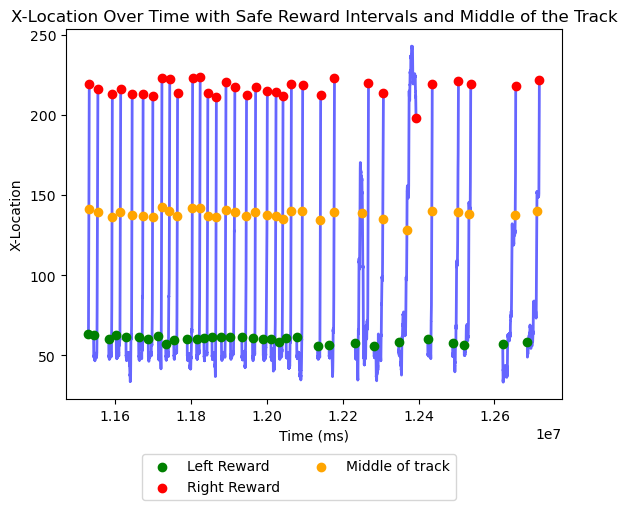

Rat11-20150316


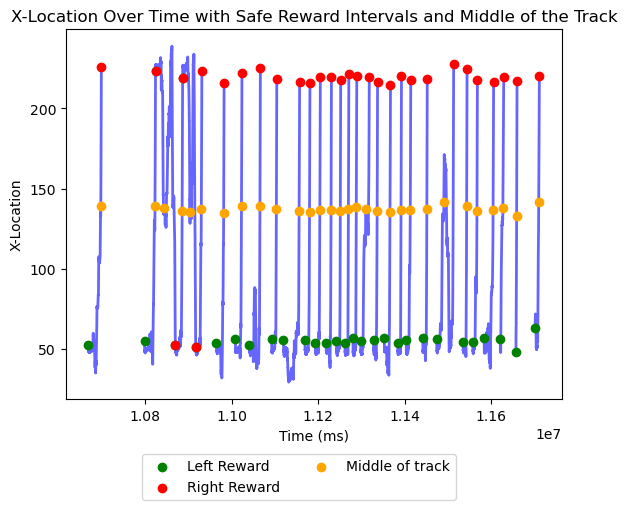

Rat11-20150317


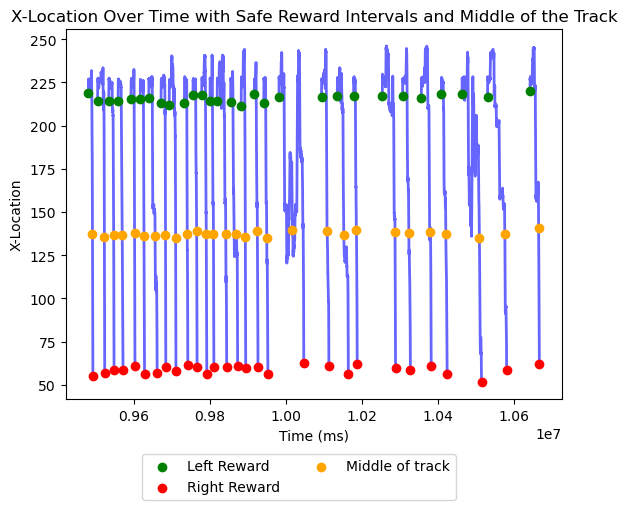

Rat11-20150321


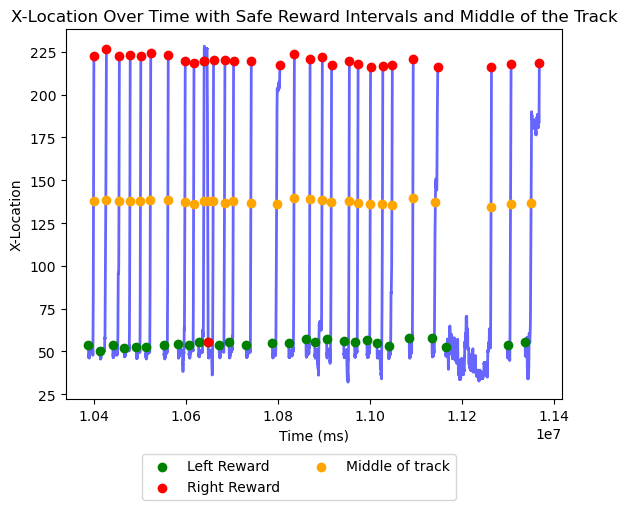

Rat11-20150323


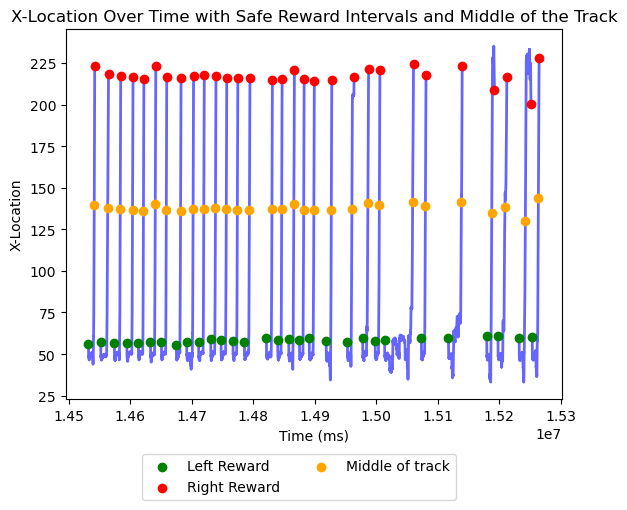

Rat11-20150325


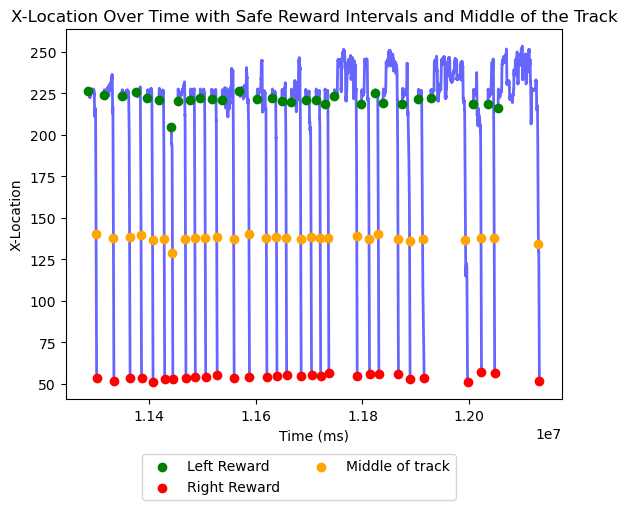

Rat11-20150326


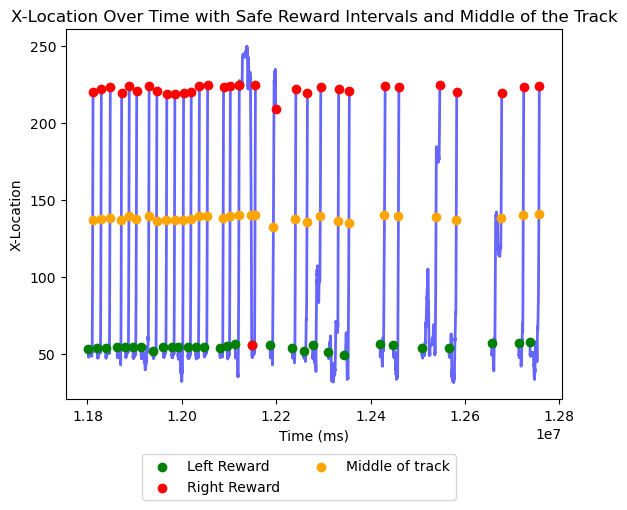

Rat11-20150328


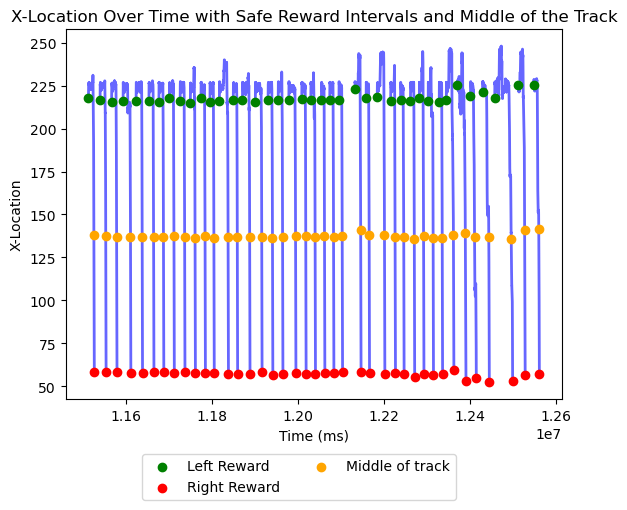

Rat11-20150330


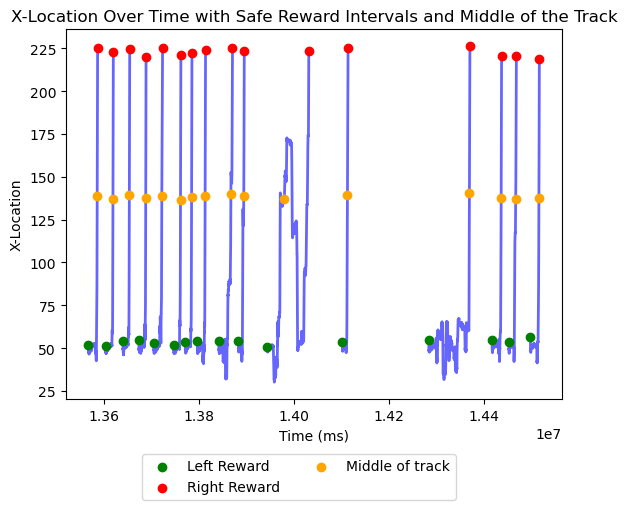

Rat11-20150331


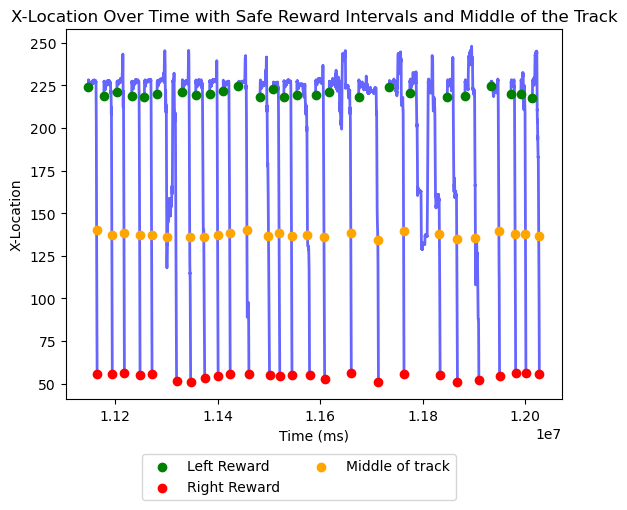

Rat11-20150401


In [58]:
session_data_rat11_middle_split = {}
for i in range(5, 15):

    # Initialize variables for session
    neuron_ids, n_neurons, session, session_neurons, begin_run_t, end_run_t = session_variable(int(i))
    n_neurons_session.append(n_neurons)
    x, y, time_location, x_run, y_run, time_run, puff_ts, puff_x_location, puff_y_location, x_mean = position_variable(session)
    left_reward_times = data.events[rat][session]['lrw']['ts']
    right_reward_times = data.events[rat][session]['rrw']['ts']
    left_reward_ts, right_reward_ts = preprocess_rewards(left_reward_times, right_reward_times, begin_run_t, end_run_t, time_run)

    # Get the matrix for the current session
    safe_runs_without_middle = exclude_airpuff_periods_matrix(left_reward_ts, right_reward_ts, puff_ts)
    safe_runs_WITH_middle = safe_runs_with_middle(safe_runs_without_middle, x_run)
    plot_safe_runs_with_middle(safe_runs_WITH_middle, x_run, time_run)
    session_matrices.append(safe_runs_WITH_middle)

    test_matrix, train_matrix = get_test_and_train_runs(safe_runs_WITH_middle)
    spk_matrix_train = init_spk_matrix_train_safe_runs(train_matrix, session, n_neurons, neuron_ids, session_neurons)
    print(session)
    session_data_rat11_middle_split[session] = {
        "test_matrix": test_matrix,
        "train_matrix": train_matrix,
        "session_neurons": session_neurons,
        "n_neurons": n_neurons,
        "neuron_ids": neuron_ids
    }

# Access test and train matrices for a specific session
# print(session_data[session]["test_matrix"])
 


In [59]:
print(n_neurons_session)


with open("rat11_session_data_middle.pkl", "wb") as pkl_file:
    pickle.dump(session_data_rat11_middle_split, pkl_file)

[52, 41, 8, 2, 6, 24, 44, 50, 76, 15]


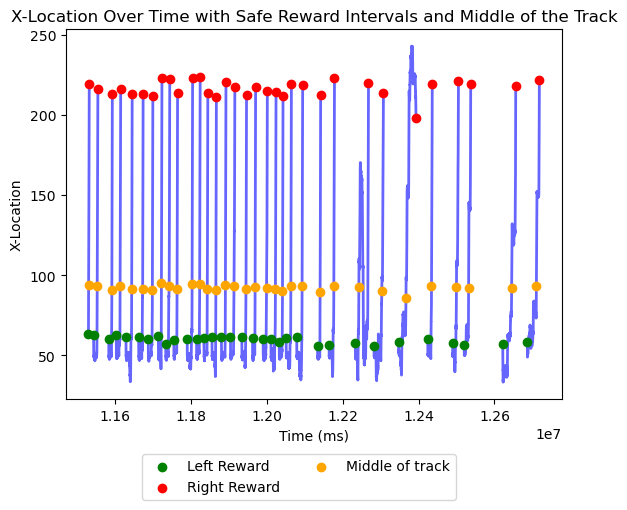

Rat11-20150316


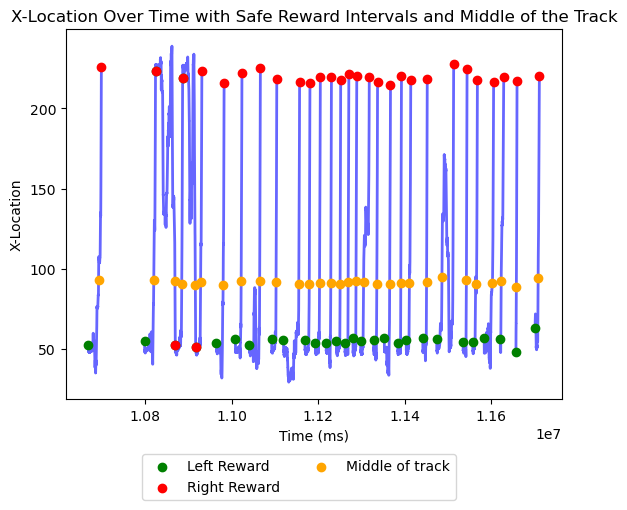

Rat11-20150317


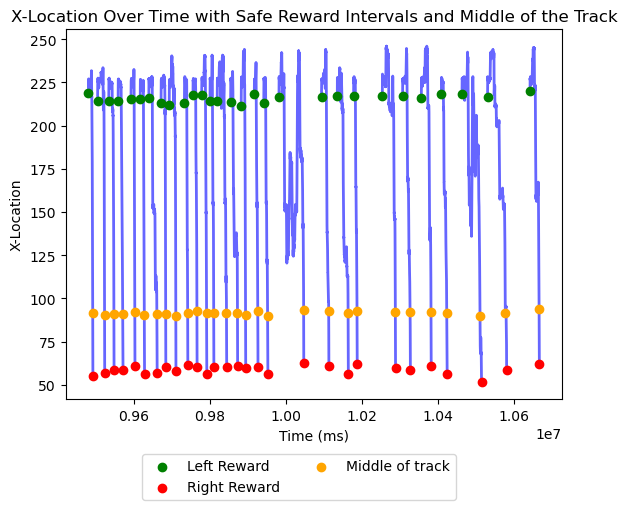

Rat11-20150321


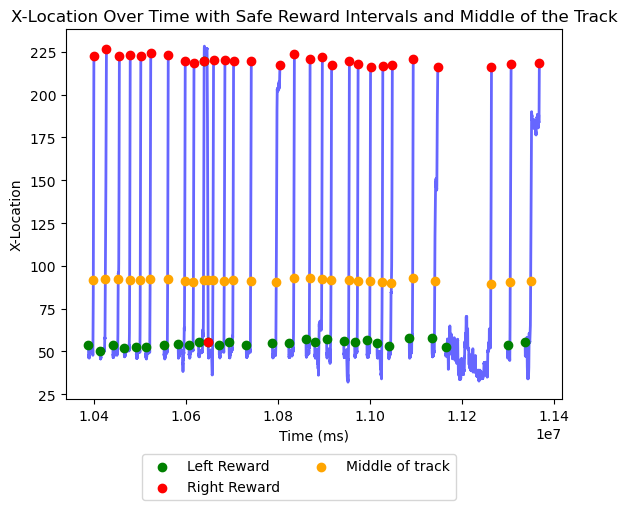

Rat11-20150323


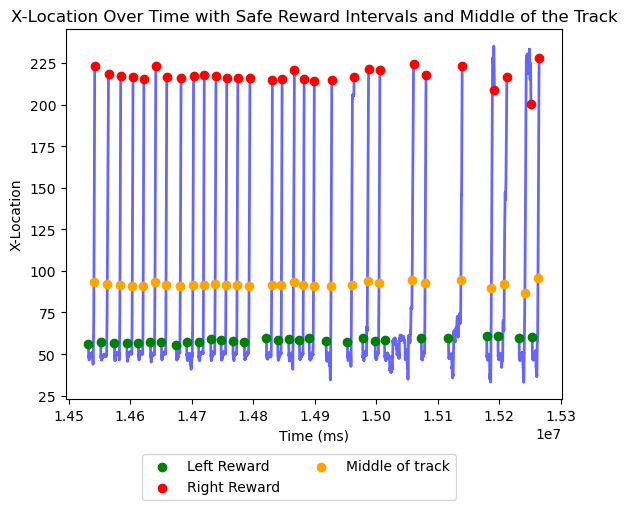

Rat11-20150325


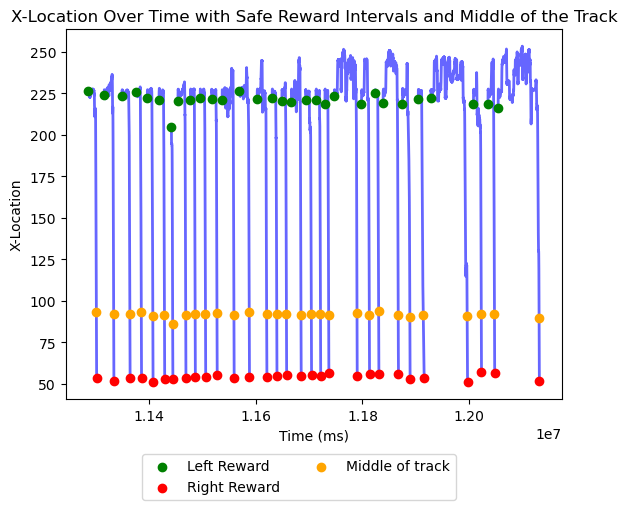

Rat11-20150326


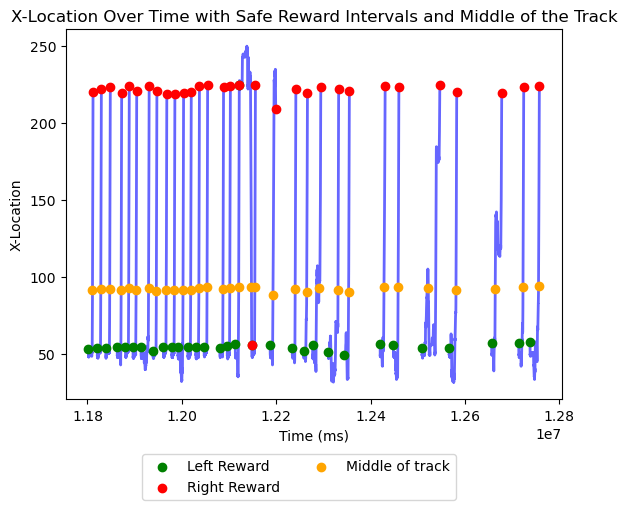

Rat11-20150328


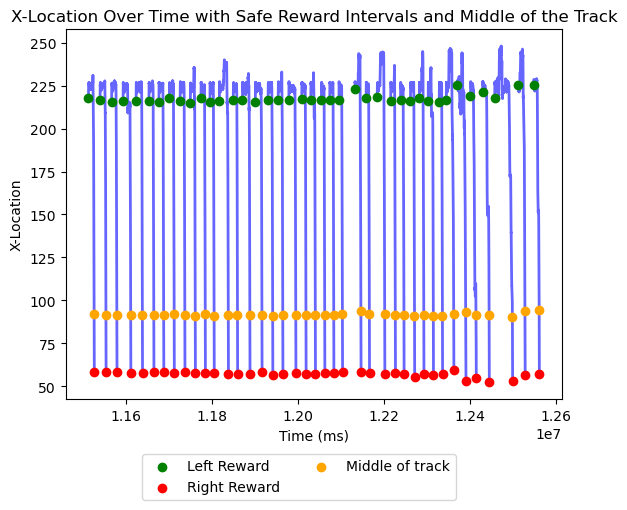

Rat11-20150330


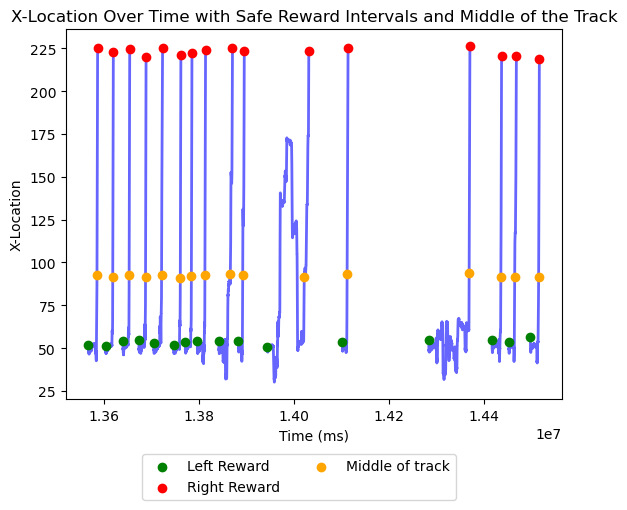

Rat11-20150331


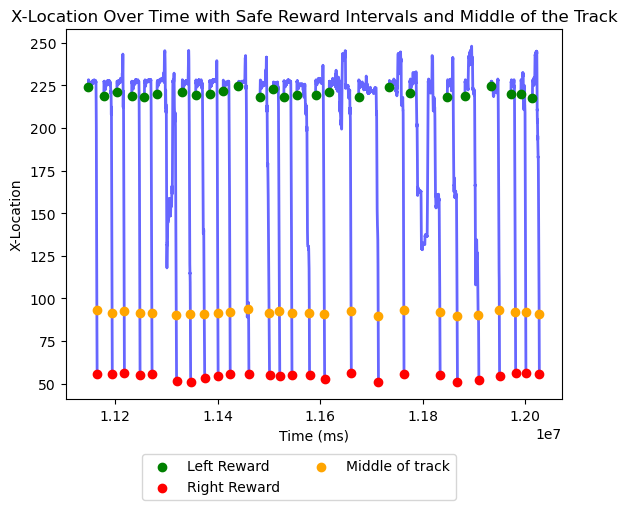

Rat11-20150401


In [12]:
session_data_rat11_third_split = {}
for i in range(5, 15):

    neuron_ids, n_neurons, session, session_neurons, begin_run_t, end_run_t = session_variable(int(i))
    x, y, time_location, x_run, y_run, time_run, puff_ts, puff_x_location, puff_y_location, x_mean = position_variable(session)
    left_reward_times = data.events[rat][session]['lrw']['ts']
    right_reward_times = data.events[rat][session]['rrw']['ts']
    left_reward_ts, right_reward_ts = preprocess_rewards(left_reward_times, right_reward_times, begin_run_t, end_run_t, time_run)

    # Get the matrix for the current session
    safe_runs_without_third = exclude_airpuff_periods_matrix(left_reward_ts, right_reward_ts, puff_ts)
    safe_runs_WITH_third = safe_runs_with_third(safe_runs_without_third, x_run)
    plot_safe_runs_with_third(safe_runs_WITH_third, x_run, time_run)
    session_matrices.append(safe_runs_WITH_third)

    test_matrix, train_matrix = get_test_and_train_runs(safe_runs_WITH_third)
    spk_matrix_train = init_spk_matrix_train_safe_runs(train_matrix, session, n_neurons, neuron_ids, session_neurons)
    print(session)
    session_data_rat11_third_split[session] = {
        "test_matrix": test_matrix,
        "train_matrix": train_matrix,
        "session_neurons": session_neurons,
        "n_neurons": n_neurons,
        "neuron_ids": neuron_ids
    }

In [13]:
results_per_session_rat11_middle_split = {}


In [14]:
for session, matrices in session_data_rat11_middle_split.items():
    print(f'Analyzing session {session}')
    test_matrix = matrices["test_matrix"]
    train_matrix = matrices["train_matrix"]
    n_neurons = matrices ["n_neurons"]
    neuron_ids = matrices ["neuron_ids"]
    session_neurons = matrices["session_neurons"]
    
    spk_matrix_train = init_spk_matrix_train_safe_runs(train_matrix, session, n_neurons, neuron_ids, session_neurons)
    
    occ, mi_real, surrogates, boundary = compute_mi_occ_surrogates_per_neuron(spk_matrix_train, 120, 500)
    
    results_per_session_rat11_middle_split[session] = {
        "occ": occ,
        "mi_real": mi_real,
        "surrogates": surrogates,
        "boundary": boundary
    }
    print(f'On to next session')

Analyzing session Rat11-20150316
Analyzing neuron 0 of 52
Analyzing neuron 1 of 52
Computed ranks, occ, mi and surrogates for  1 of 52
Analyzing neuron 2 of 52
Computed ranks, occ, mi and surrogates for  2 of 52
Analyzing neuron 3 of 52
Computed ranks, occ, mi and surrogates for  3 of 52
Analyzing neuron 4 of 52
Analyzing neuron 5 of 52
Analyzing neuron 6 of 52
Computed ranks, occ, mi and surrogates for  6 of 52
Analyzing neuron 7 of 52
Computed ranks, occ, mi and surrogates for  7 of 52
Analyzing neuron 8 of 52
Computed ranks, occ, mi and surrogates for  8 of 52
Analyzing neuron 9 of 52
Analyzing neuron 10 of 52
Computed ranks, occ, mi and surrogates for  10 of 52
Analyzing neuron 11 of 52
Analyzing neuron 12 of 52
Computed ranks, occ, mi and surrogates for  12 of 52
Analyzing neuron 13 of 52
Computed ranks, occ, mi and surrogates for  13 of 52
Analyzing neuron 14 of 52
Computed ranks, occ, mi and surrogates for  14 of 52
Analyzing neuron 15 of 52
Computed ranks, occ, mi and surrogate

In [15]:
results_per_session_rat11_third_split = {}

In [16]:
for session, matrices in session_data_rat11_third_split.items():
    print(f'Analyzing session {session}')
    test_matrix = matrices["test_matrix"]
    train_matrix = matrices["train_matrix"]
    n_neurons = matrices ["n_neurons"]
    neuron_ids = matrices ["neuron_ids"]
    session_neurons = matrices["session_neurons"]
    
    spk_matrix_train = init_spk_matrix_train_safe_runs(train_matrix, session, n_neurons, neuron_ids, session_neurons)
    
    occ, mi_real, surrogates, boundary = compute_mi_occ_surrogates_per_neuron(spk_matrix_train, 120, 500)
    
    results_per_session_rat11_third_split[session] = {
        "occ": occ,
        "mi_real": mi_real,
        "surrogates": surrogates,
        "boundary": boundary
    }
    print(f'On to next session')

Analyzing session Rat11-20150316
Analyzing neuron 0 of 52
Analyzing neuron 1 of 52
Computed ranks, occ, mi and surrogates for  1 of 52
Analyzing neuron 2 of 52
Computed ranks, occ, mi and surrogates for  2 of 52
Analyzing neuron 3 of 52
Computed ranks, occ, mi and surrogates for  3 of 52
Analyzing neuron 4 of 52
Analyzing neuron 5 of 52
Analyzing neuron 6 of 52
Computed ranks, occ, mi and surrogates for  6 of 52
Analyzing neuron 7 of 52
Computed ranks, occ, mi and surrogates for  7 of 52
Analyzing neuron 8 of 52
Computed ranks, occ, mi and surrogates for  8 of 52
Analyzing neuron 9 of 52
Analyzing neuron 10 of 52
Computed ranks, occ, mi and surrogates for  10 of 52
Analyzing neuron 11 of 52
Analyzing neuron 12 of 52
Computed ranks, occ, mi and surrogates for  12 of 52
Analyzing neuron 13 of 52
Computed ranks, occ, mi and surrogates for  13 of 52
Analyzing neuron 14 of 52
Computed ranks, occ, mi and surrogates for  14 of 52
Analyzing neuron 15 of 52
Computed ranks, occ, mi and surrogate

Rat11-20150316


/var/folders/gx/7pdzybf540s07y1q49gzn5400000gn/T/ipykernel_67984/2937945953.py:8: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.imshow(sort_occ_matrix(occ_matrix)[0], aspect='auto', origin='lower')
/var/folders/gx/7pdzybf540s07y1q49gzn5400000gn/T/ipykernel_67984/2937945953.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


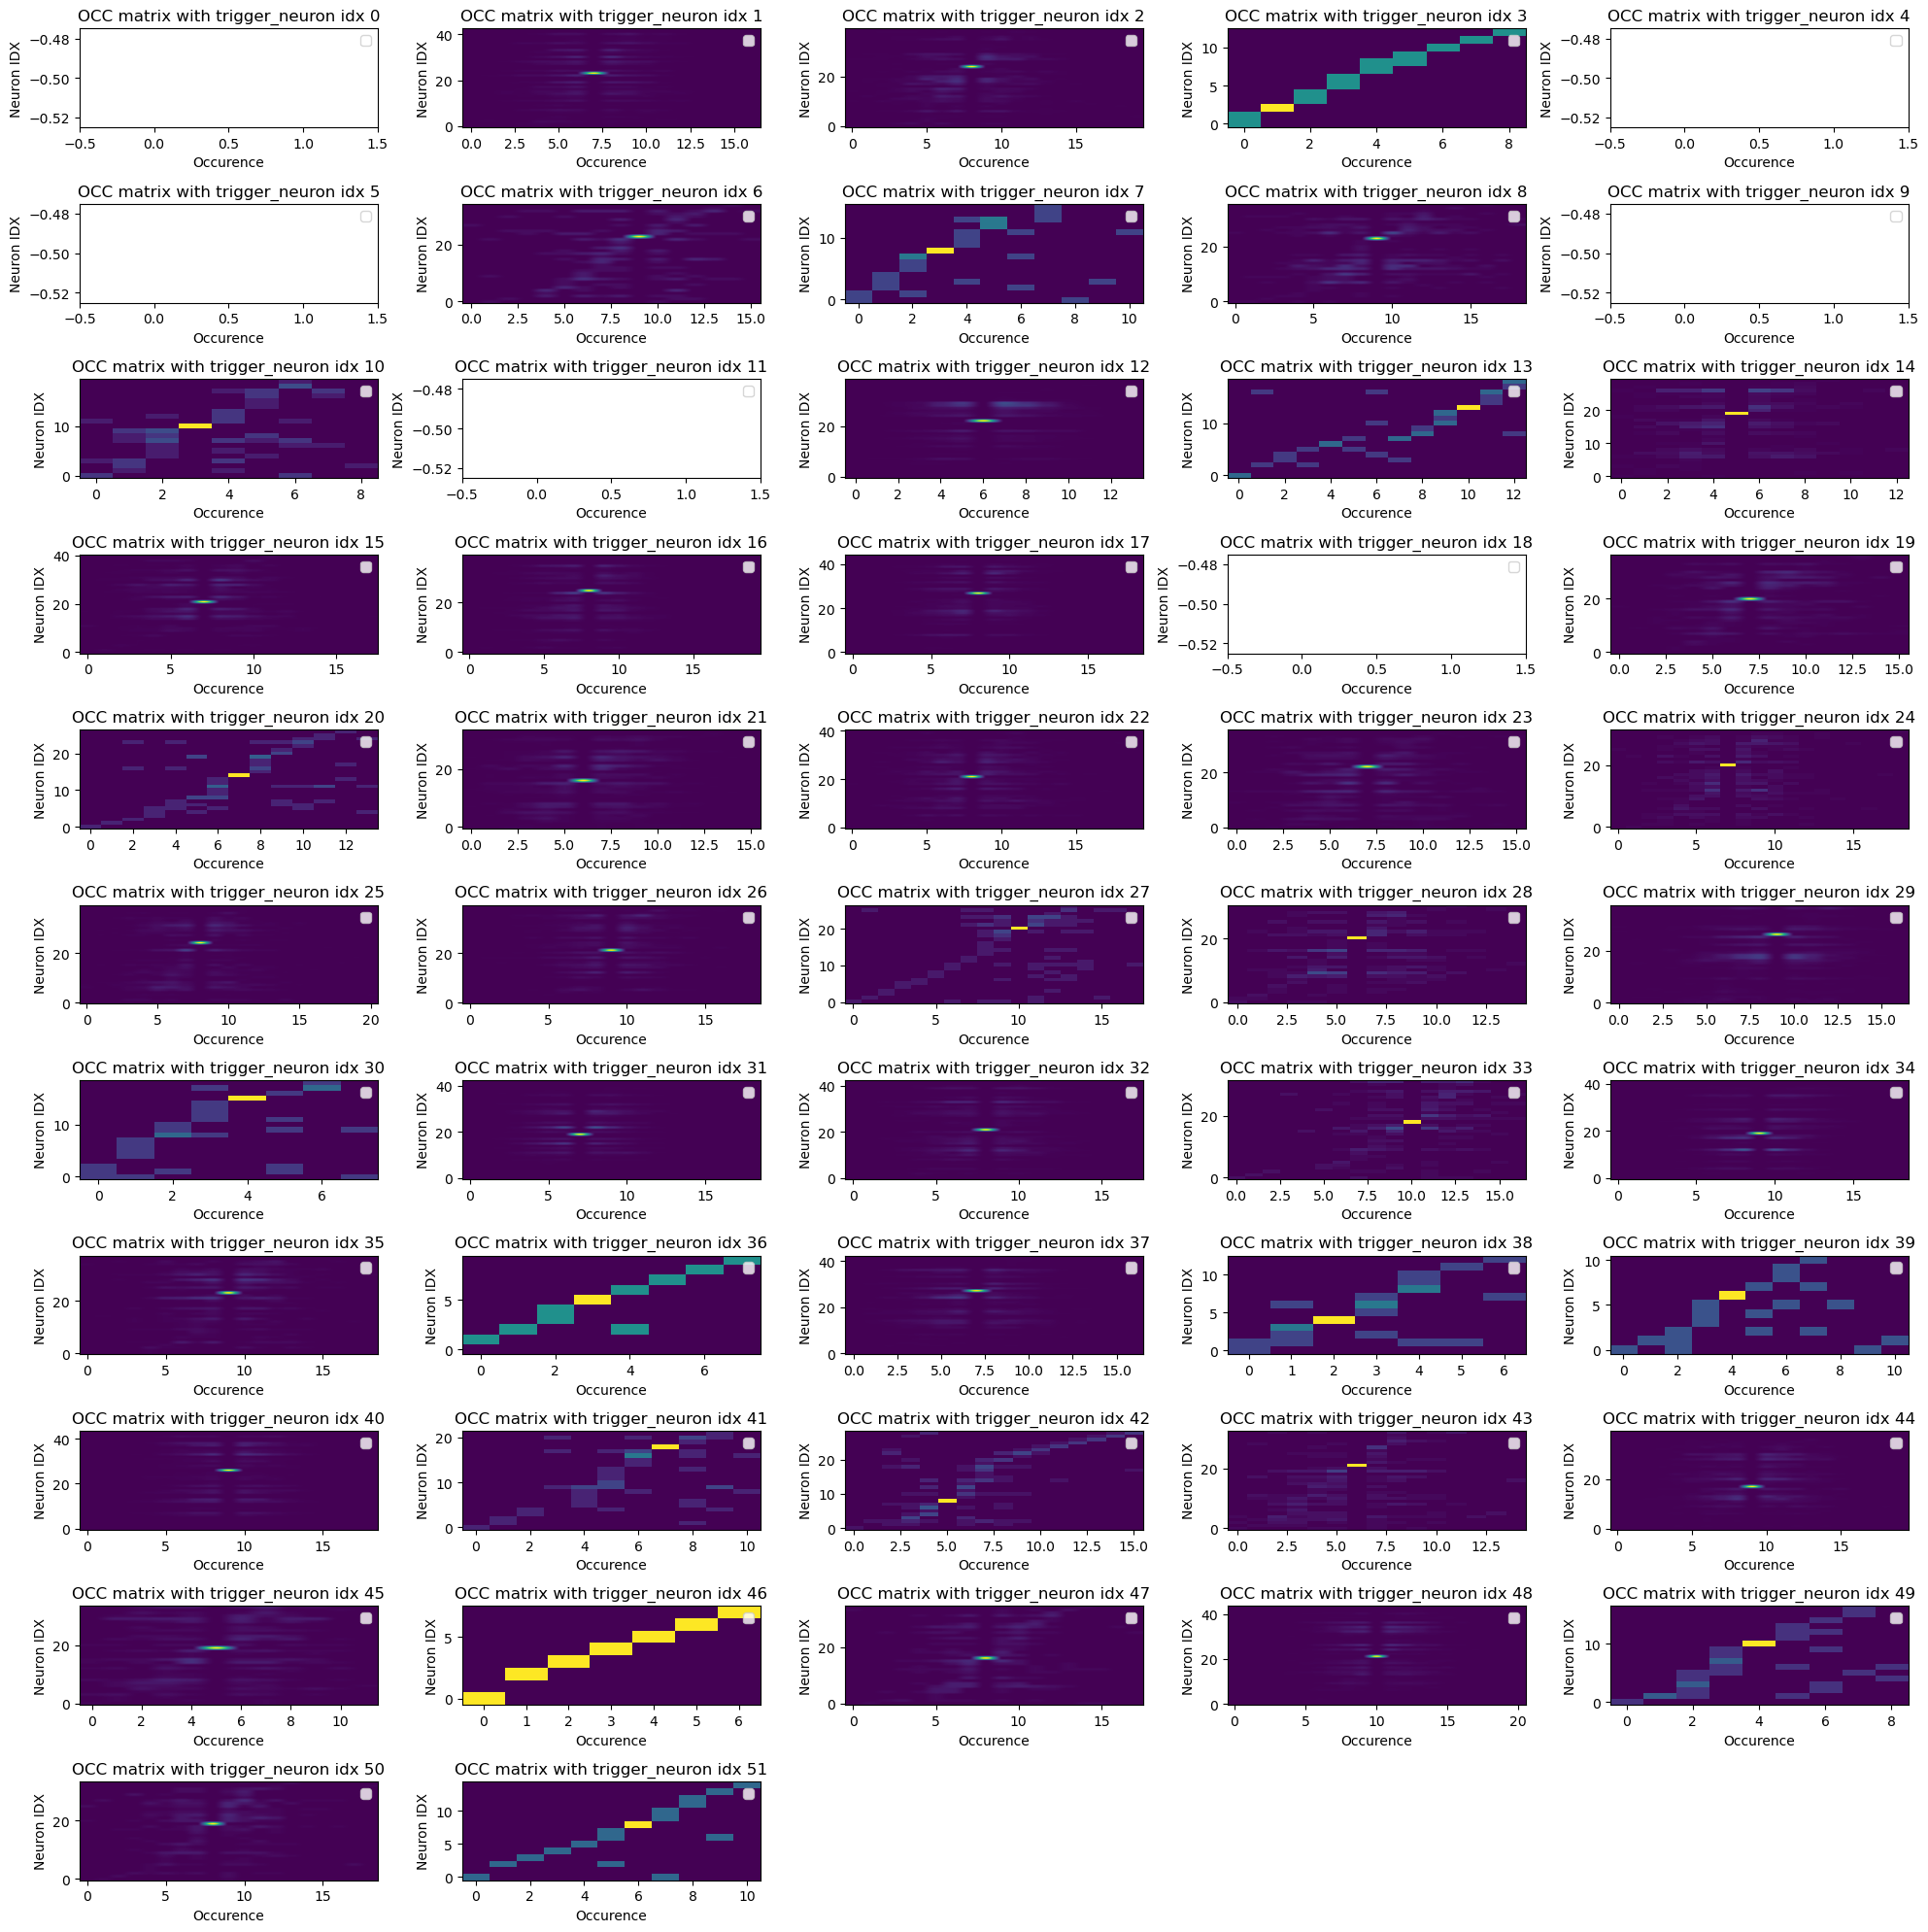

Rat11-20150317


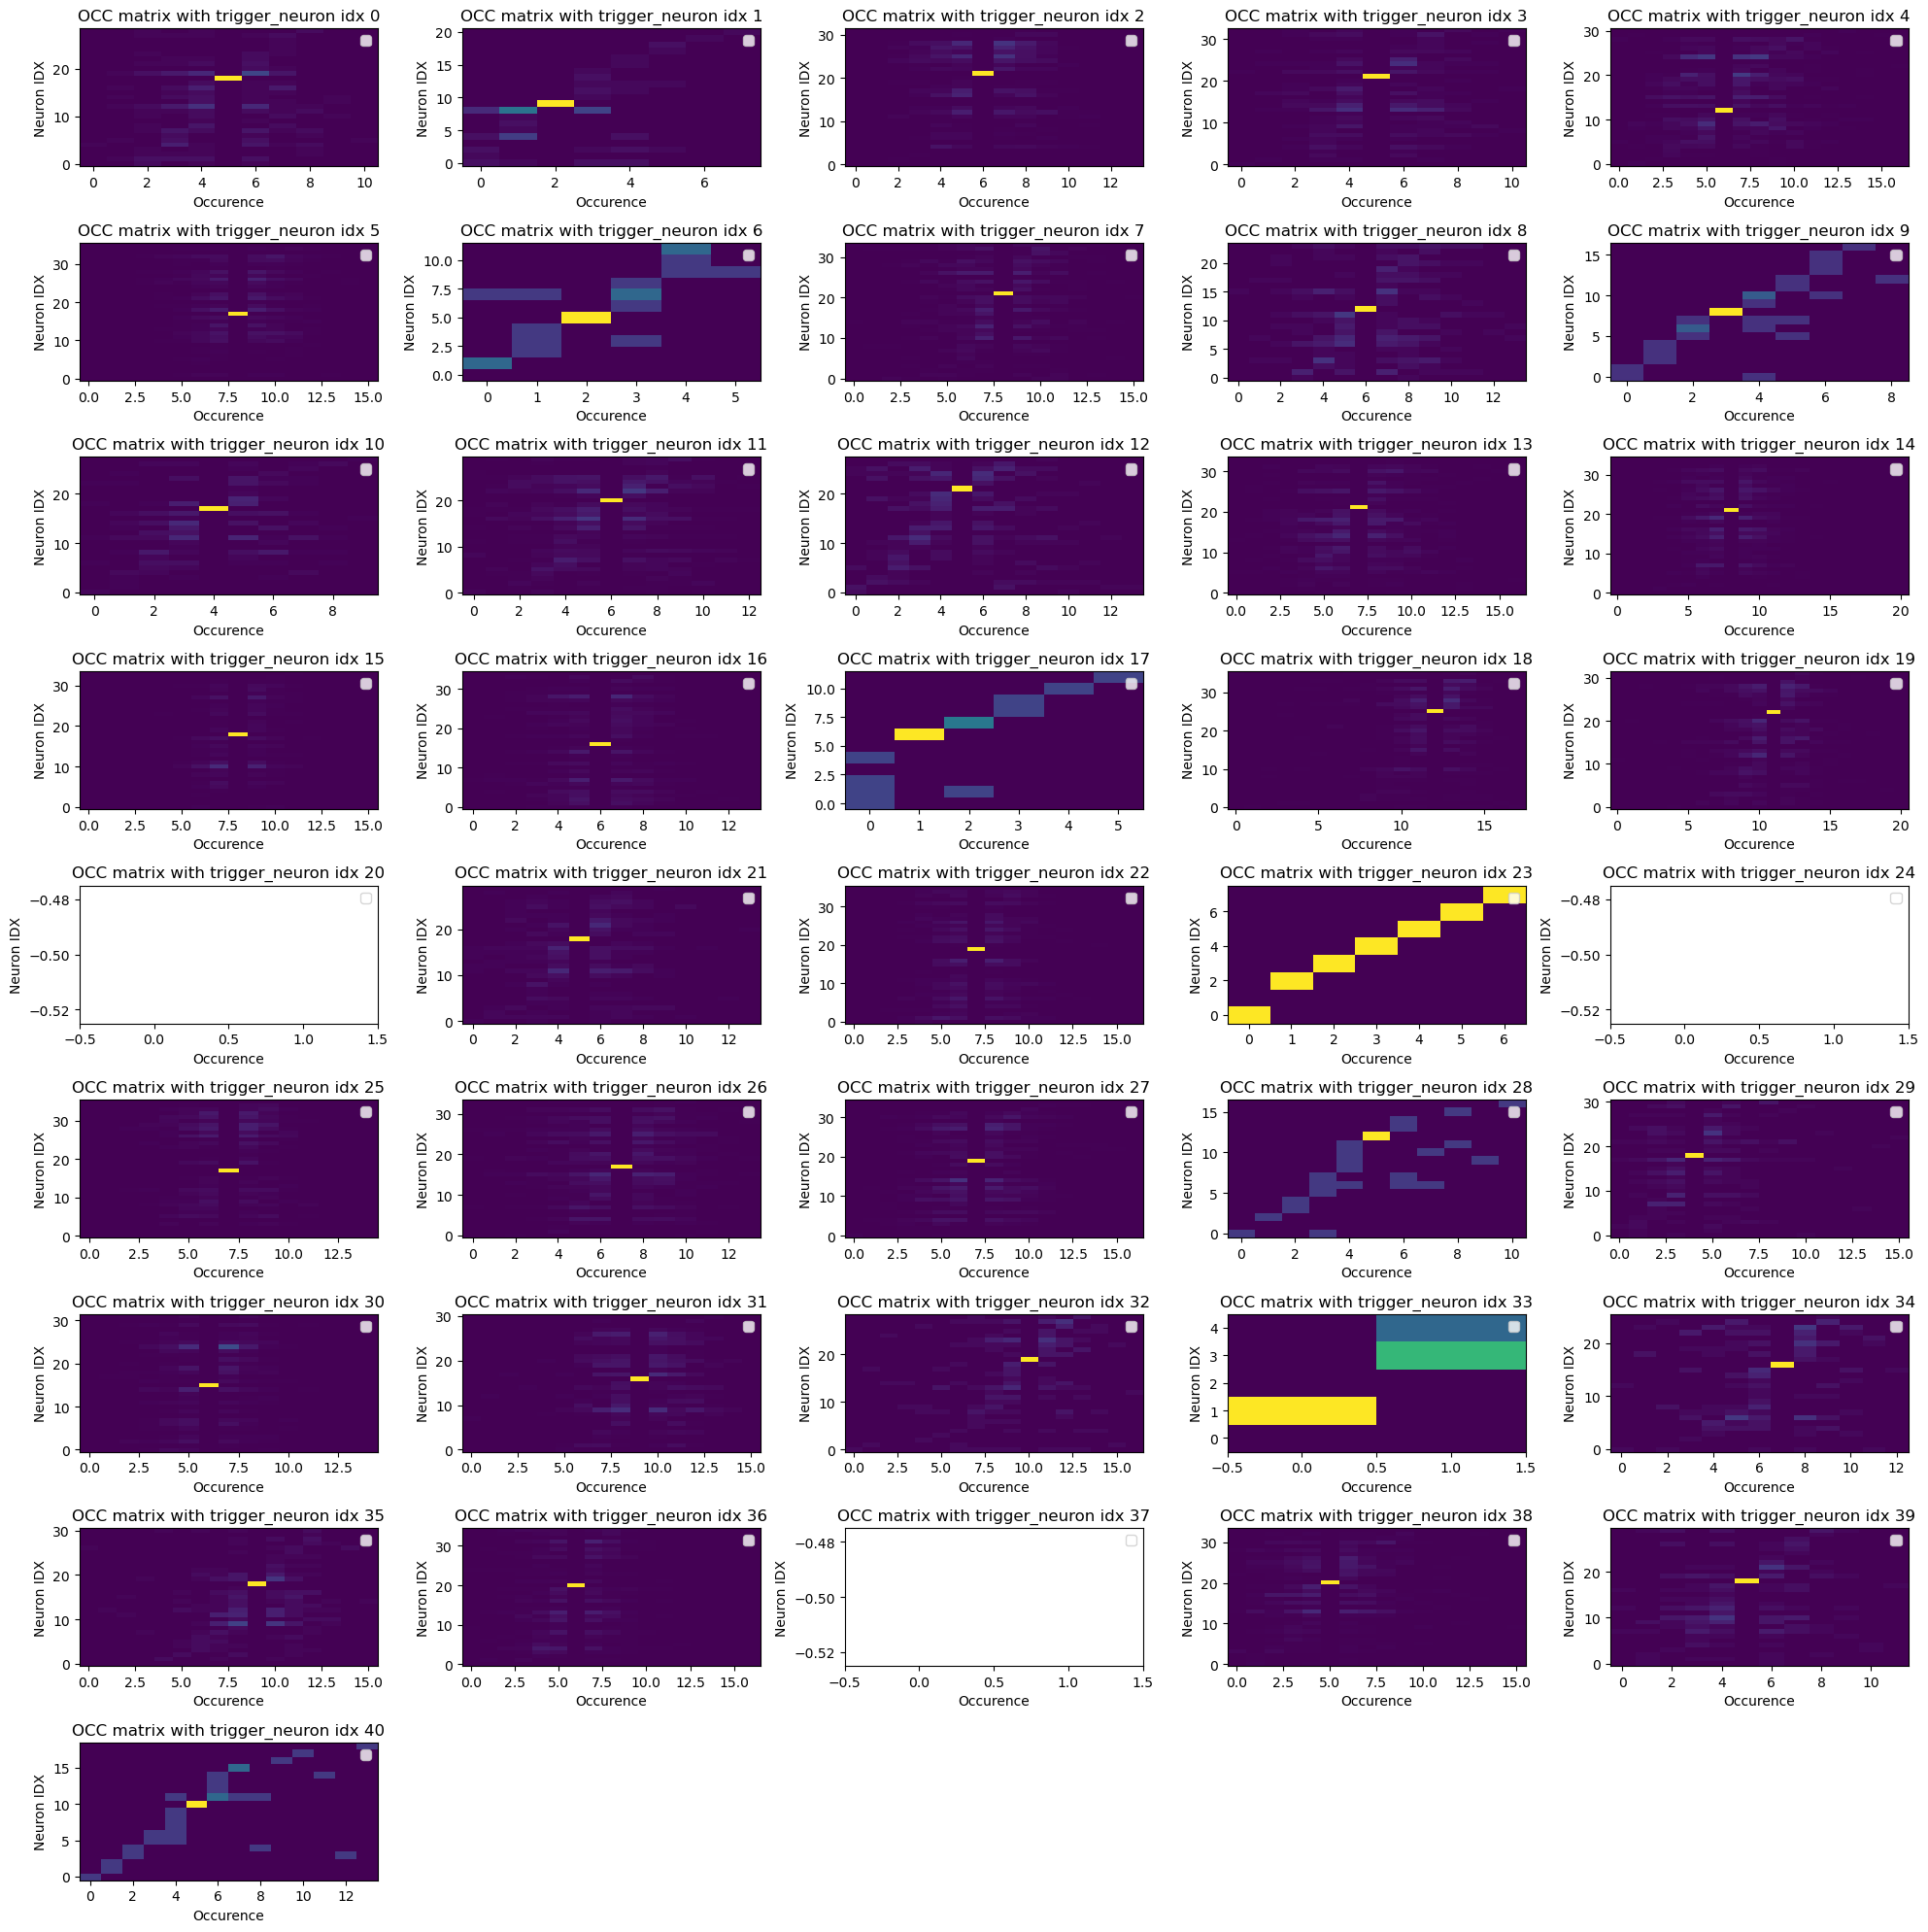

Rat11-20150321


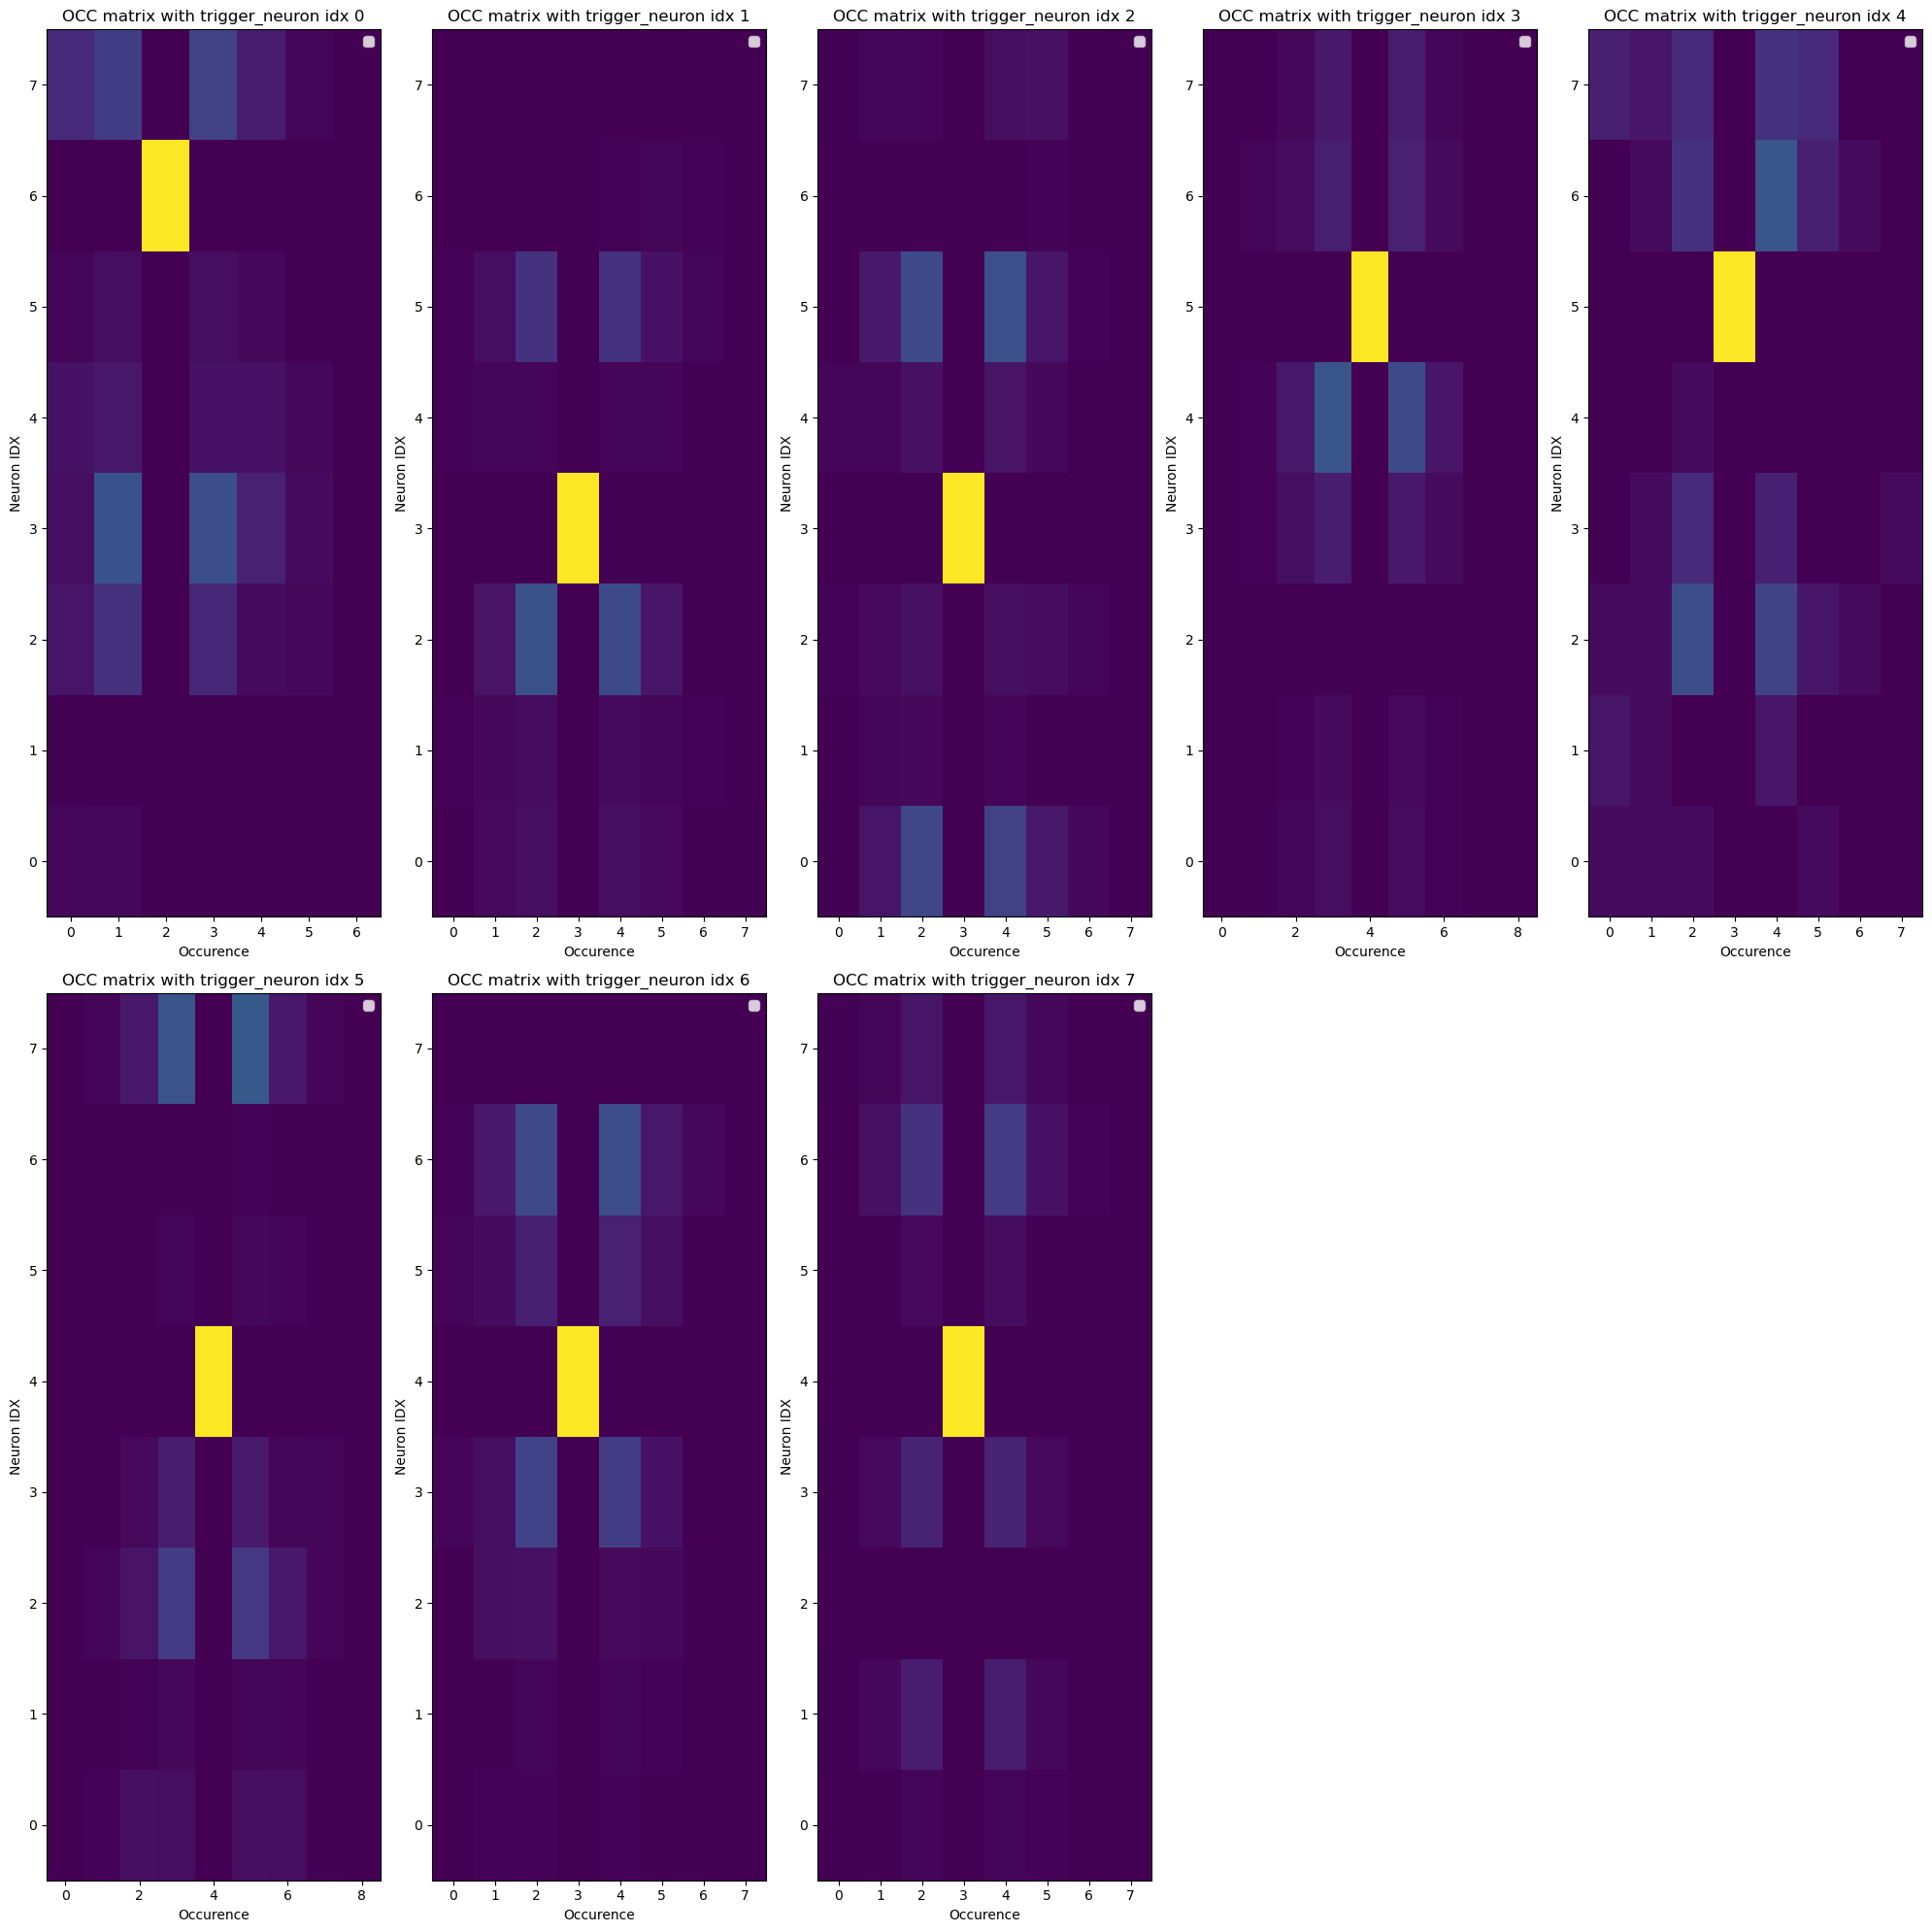

Rat11-20150323


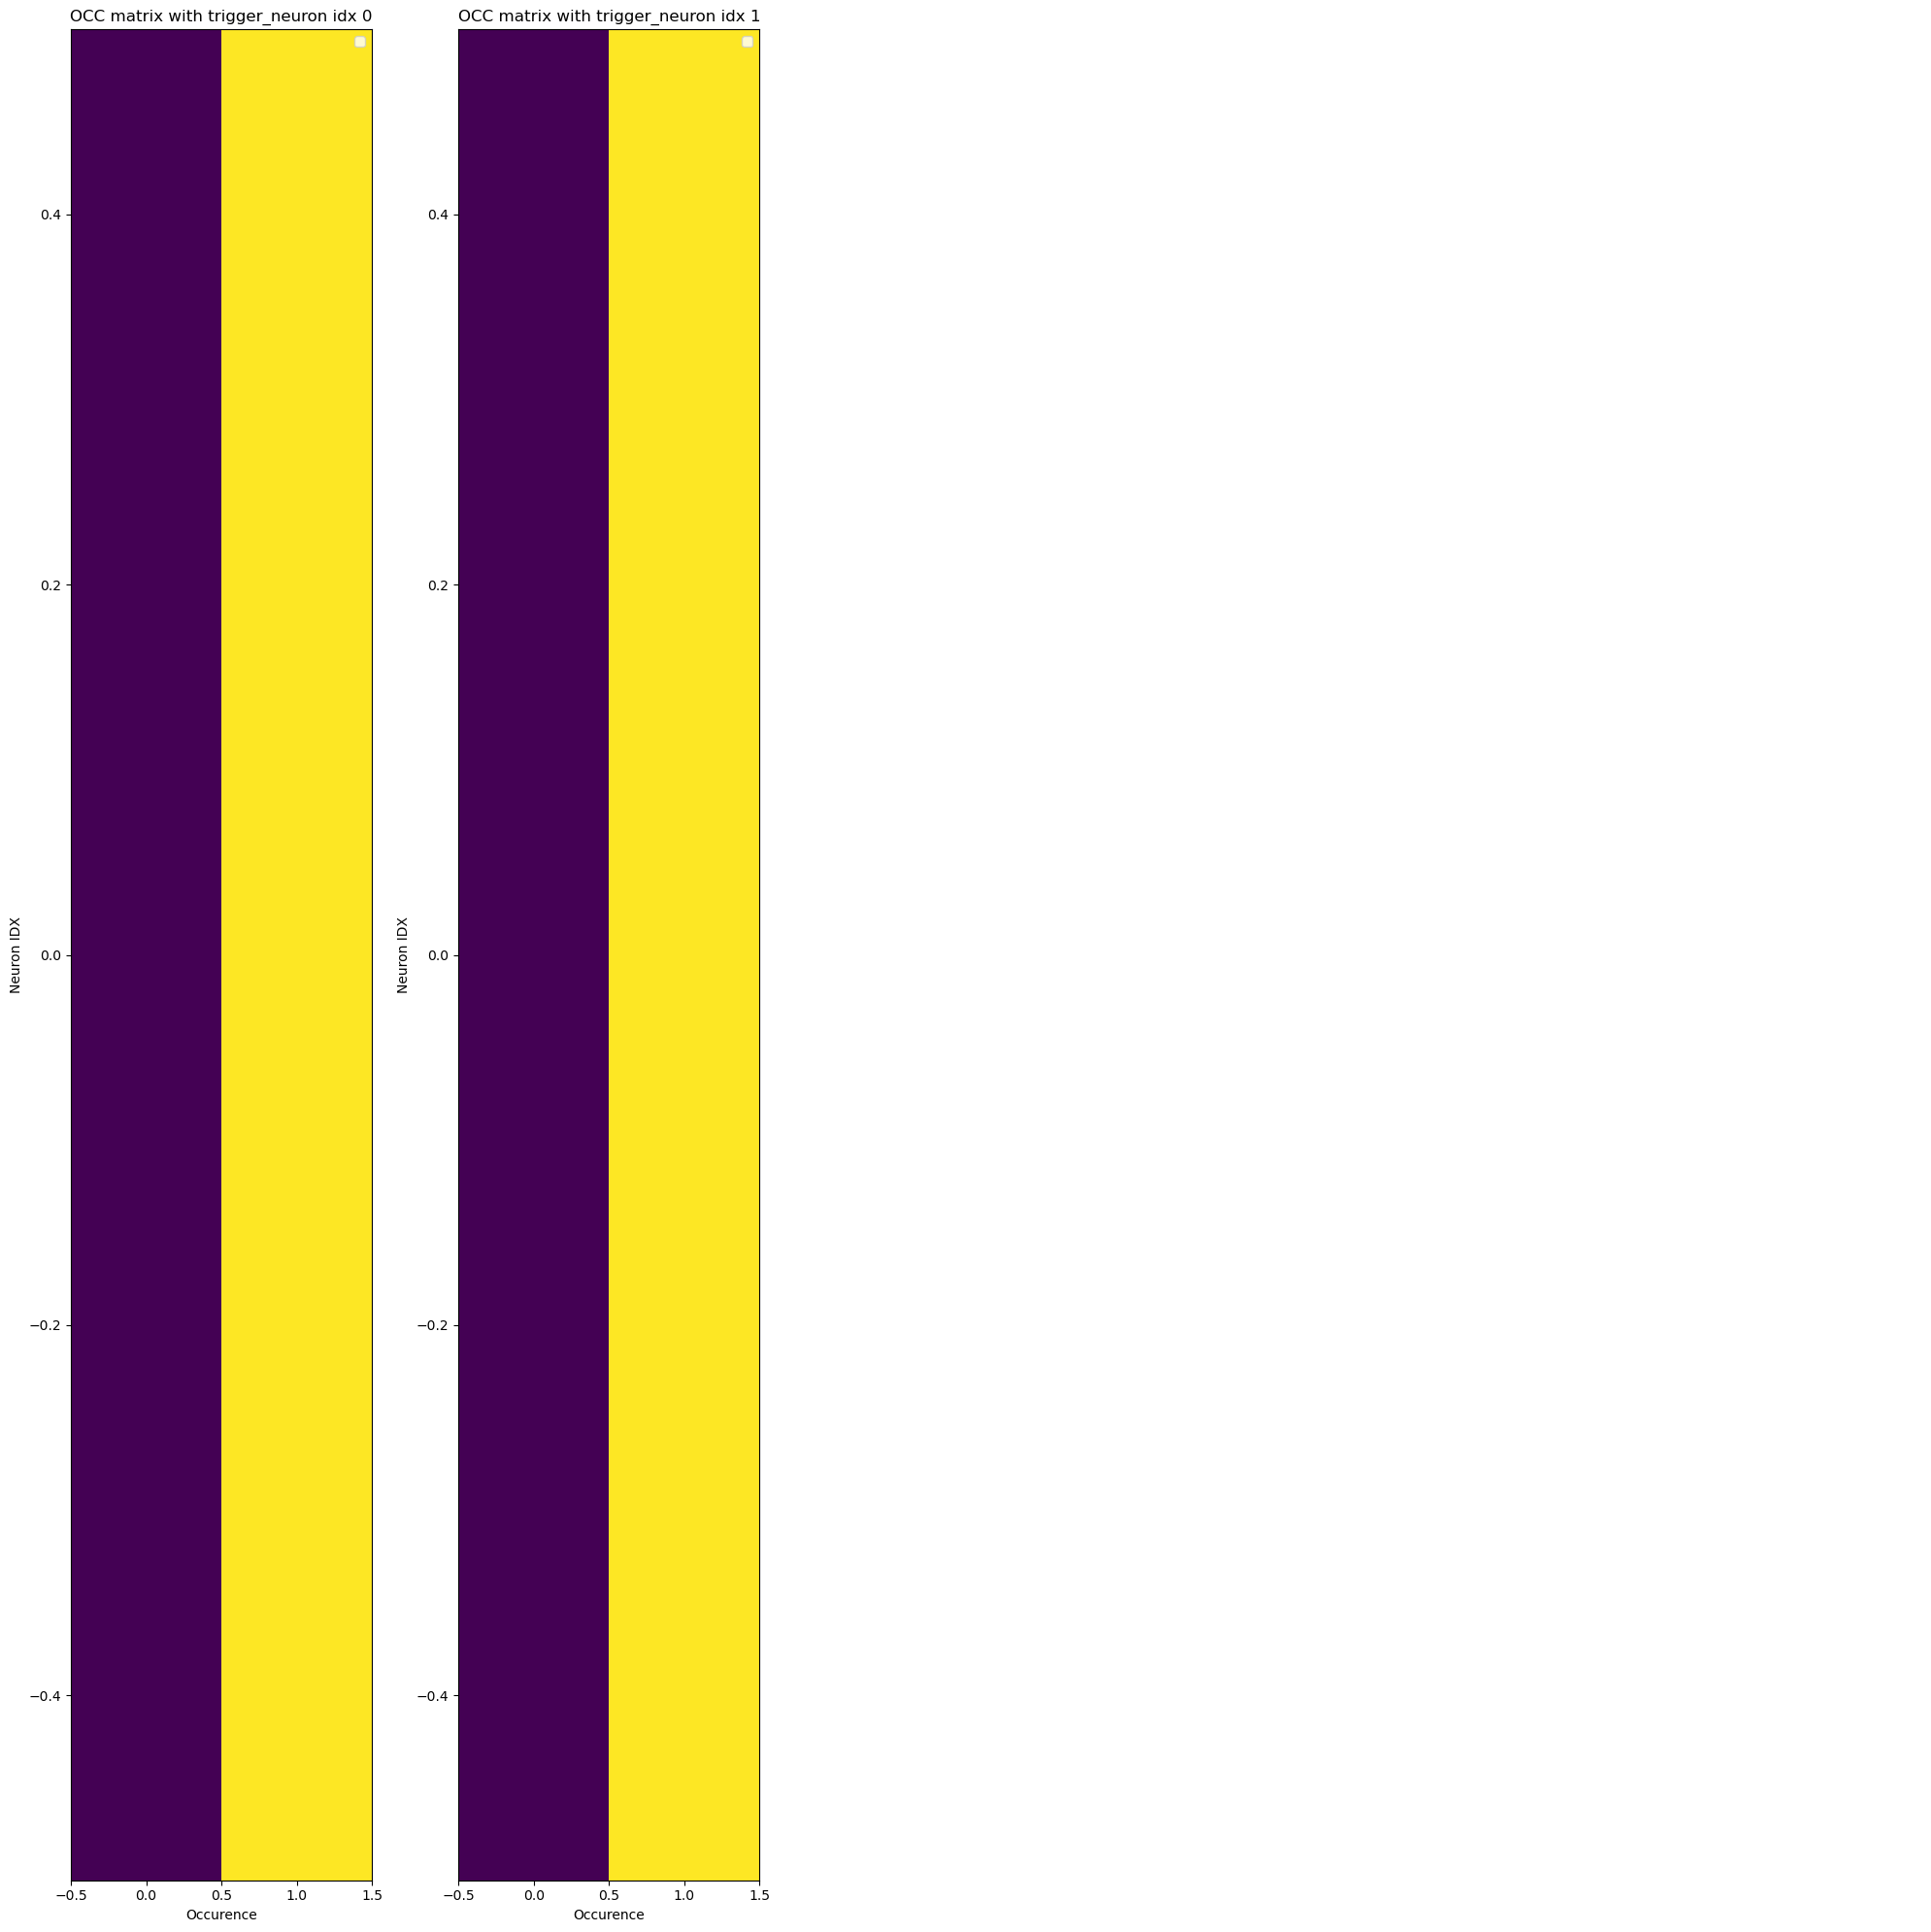

Rat11-20150325


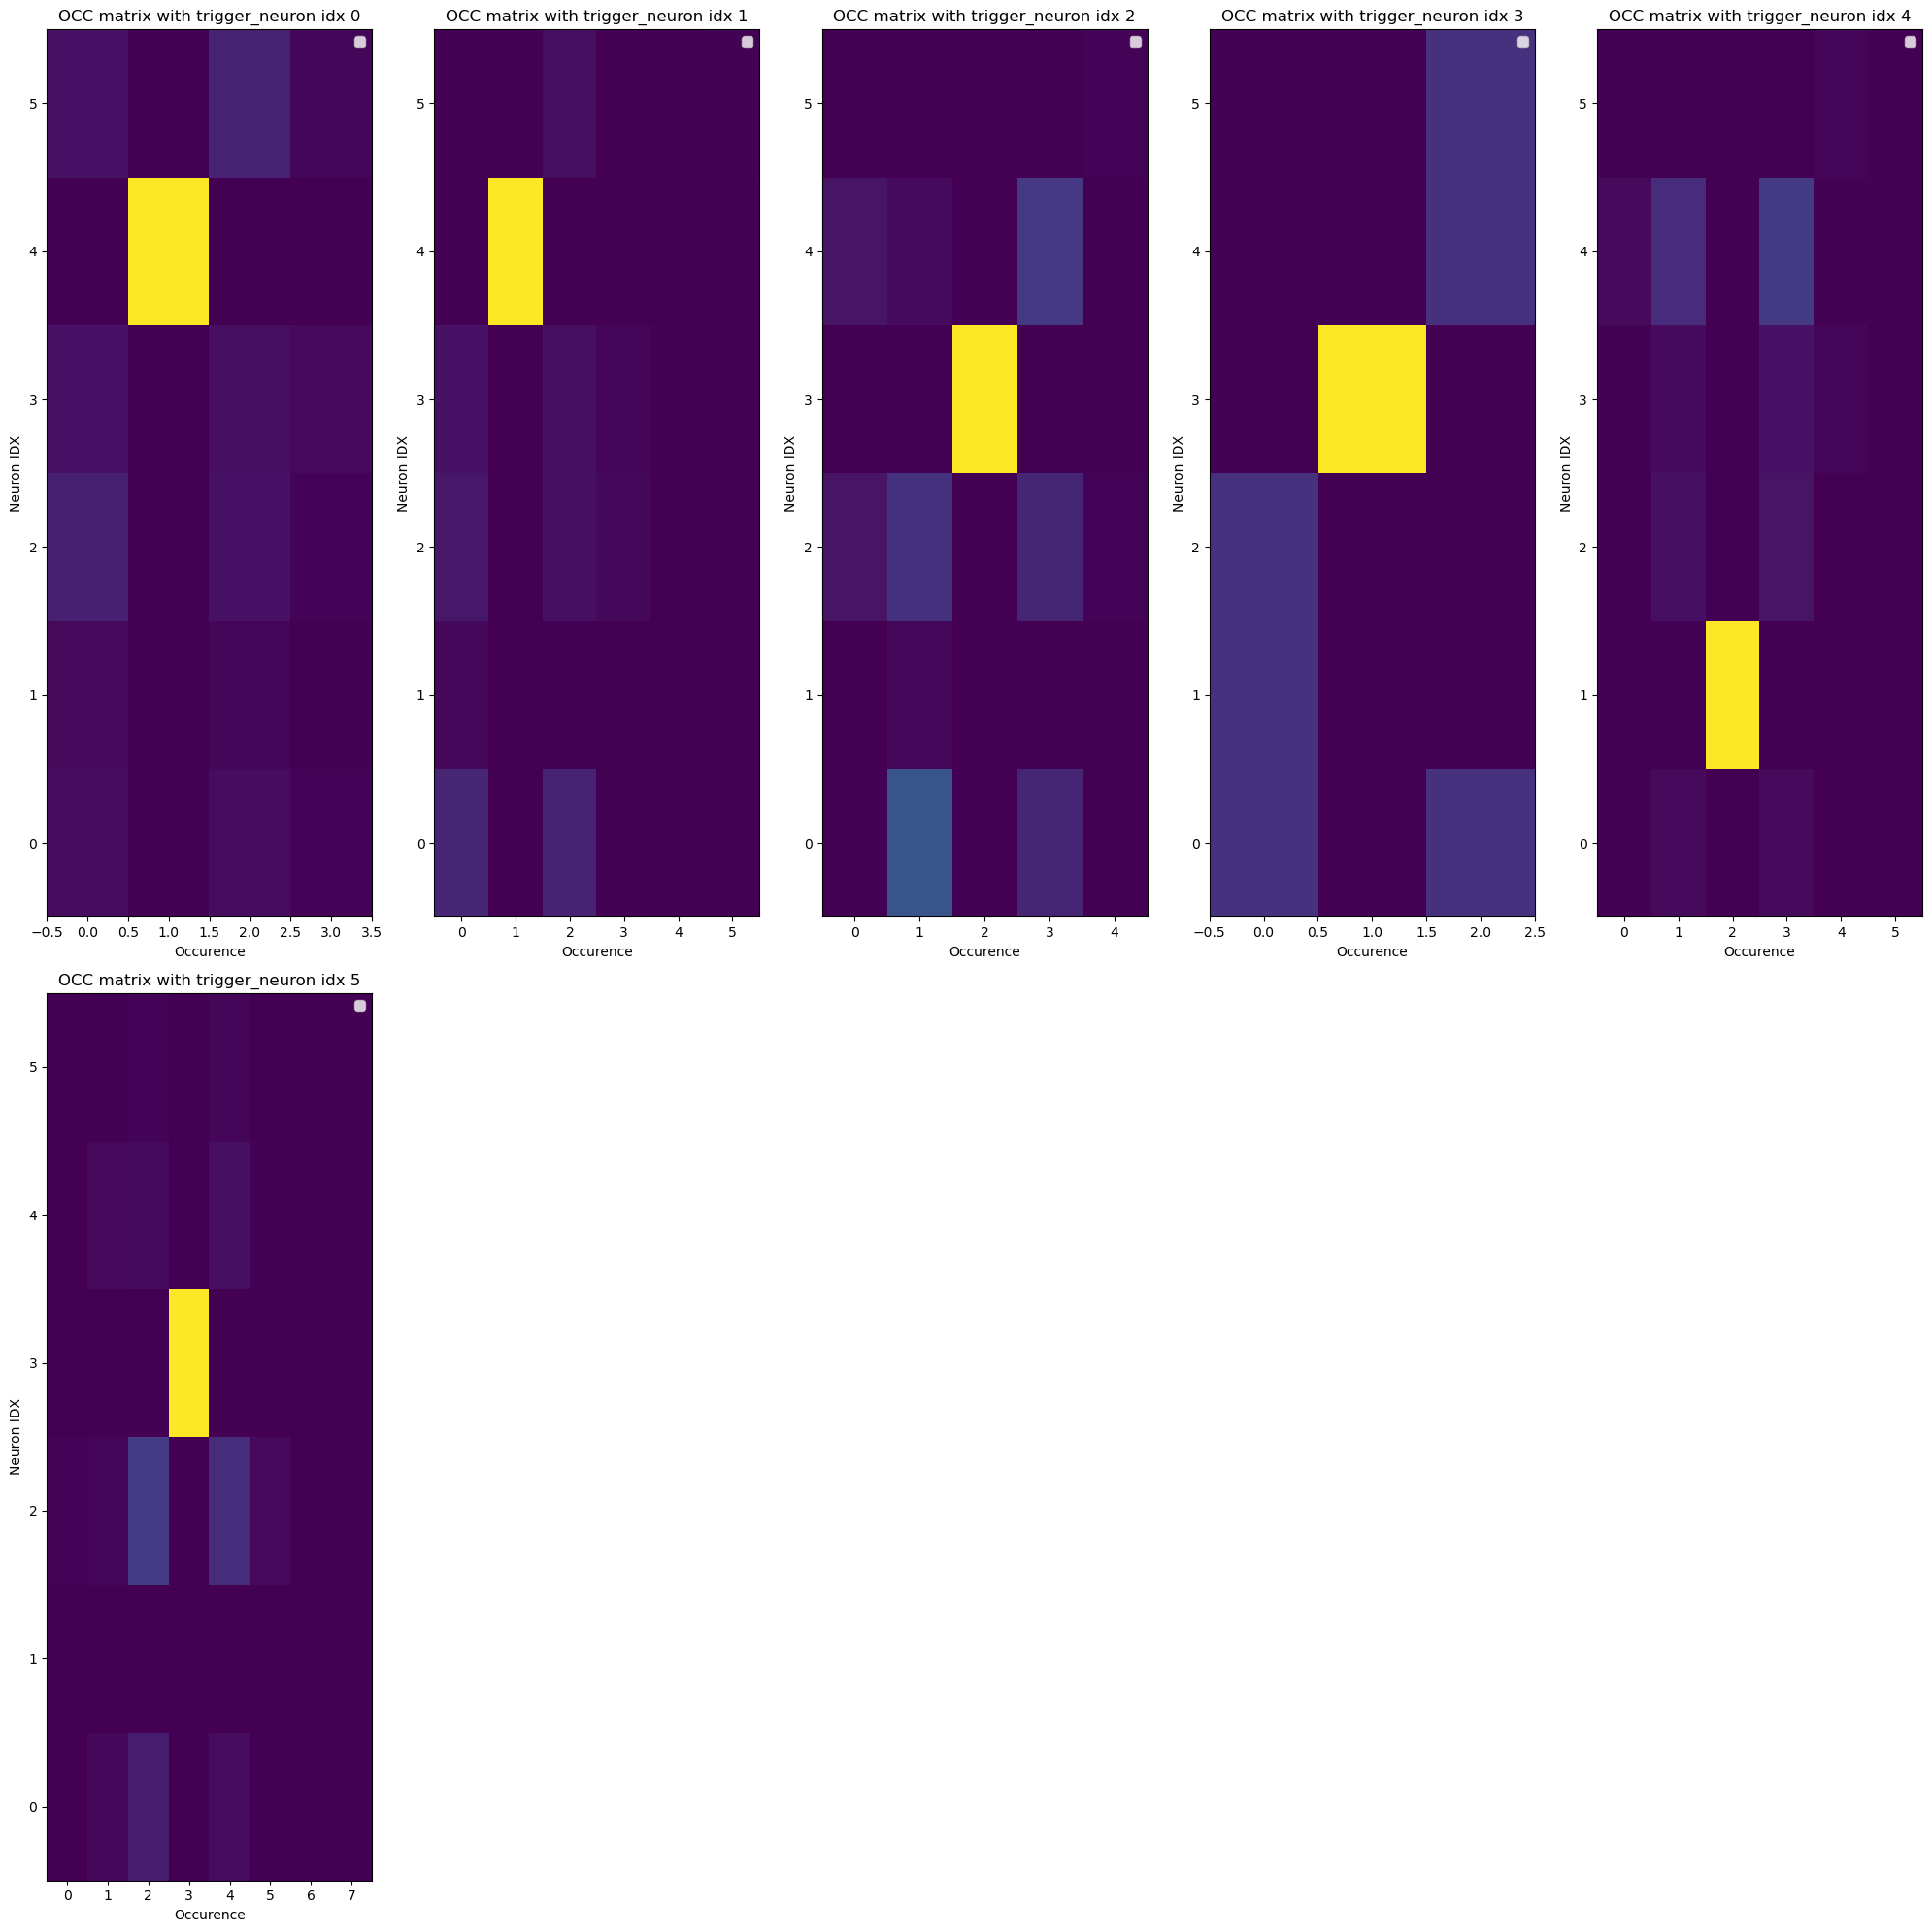

Rat11-20150326


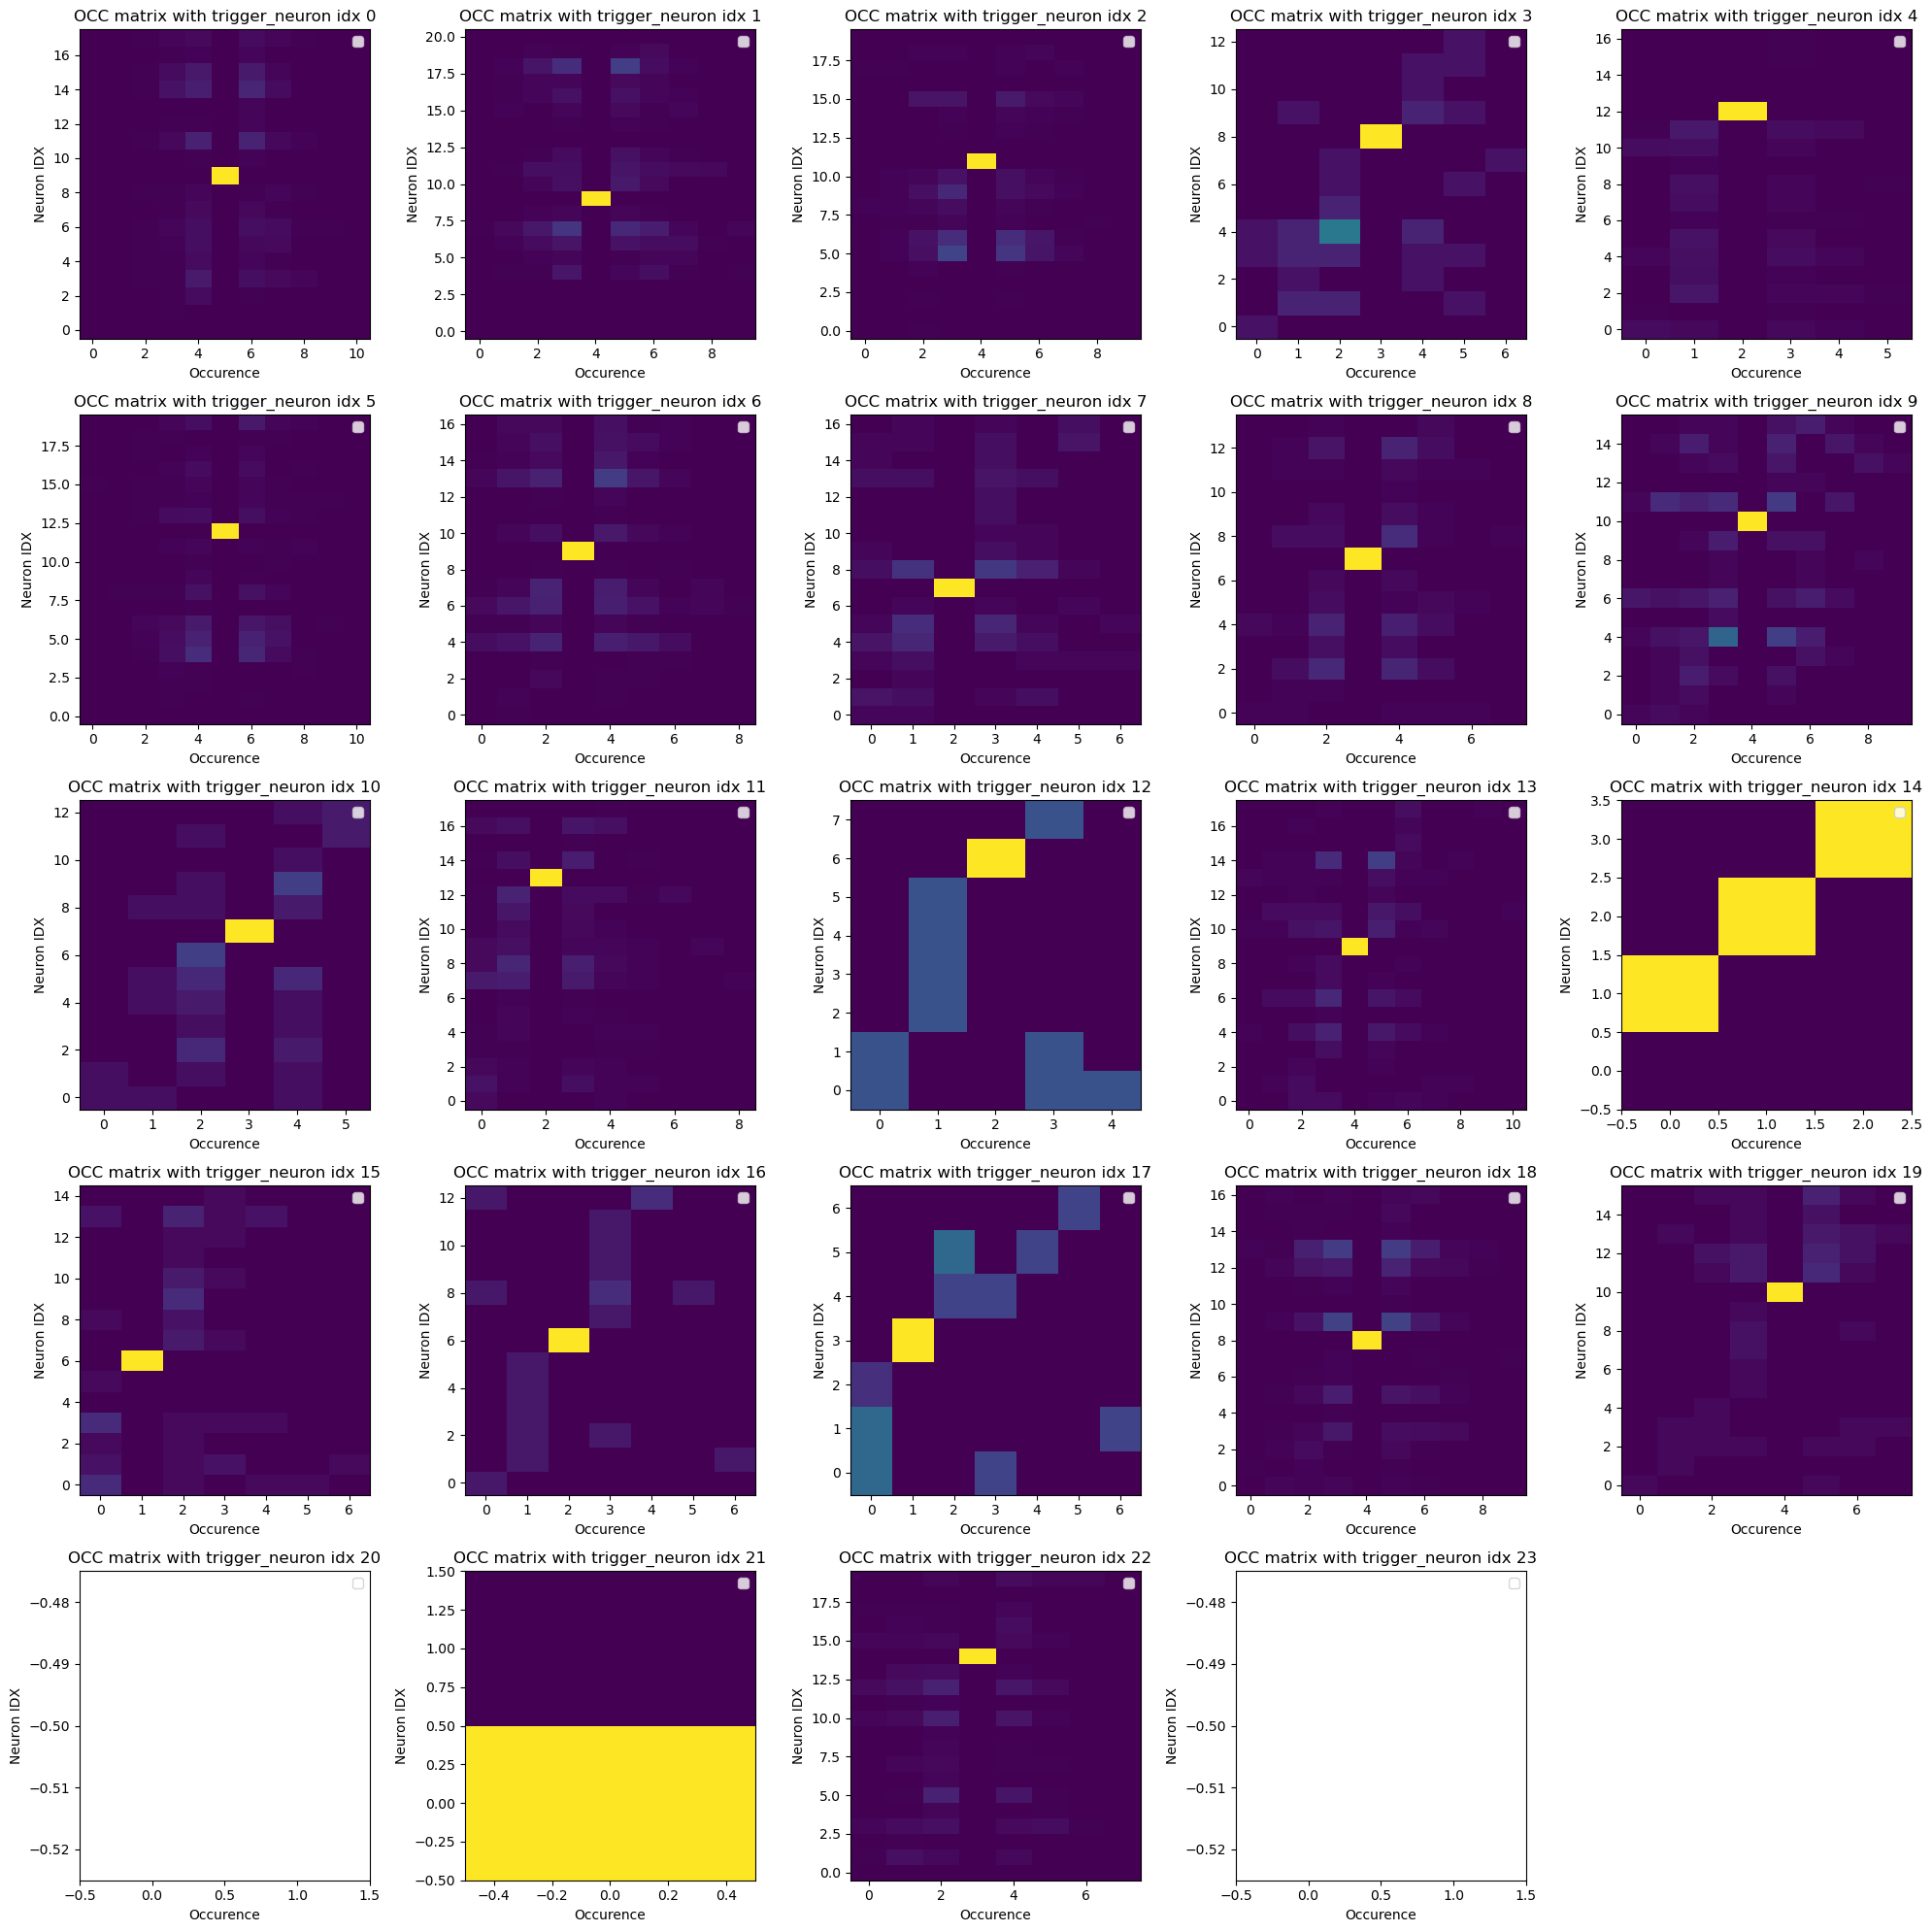

Rat11-20150328


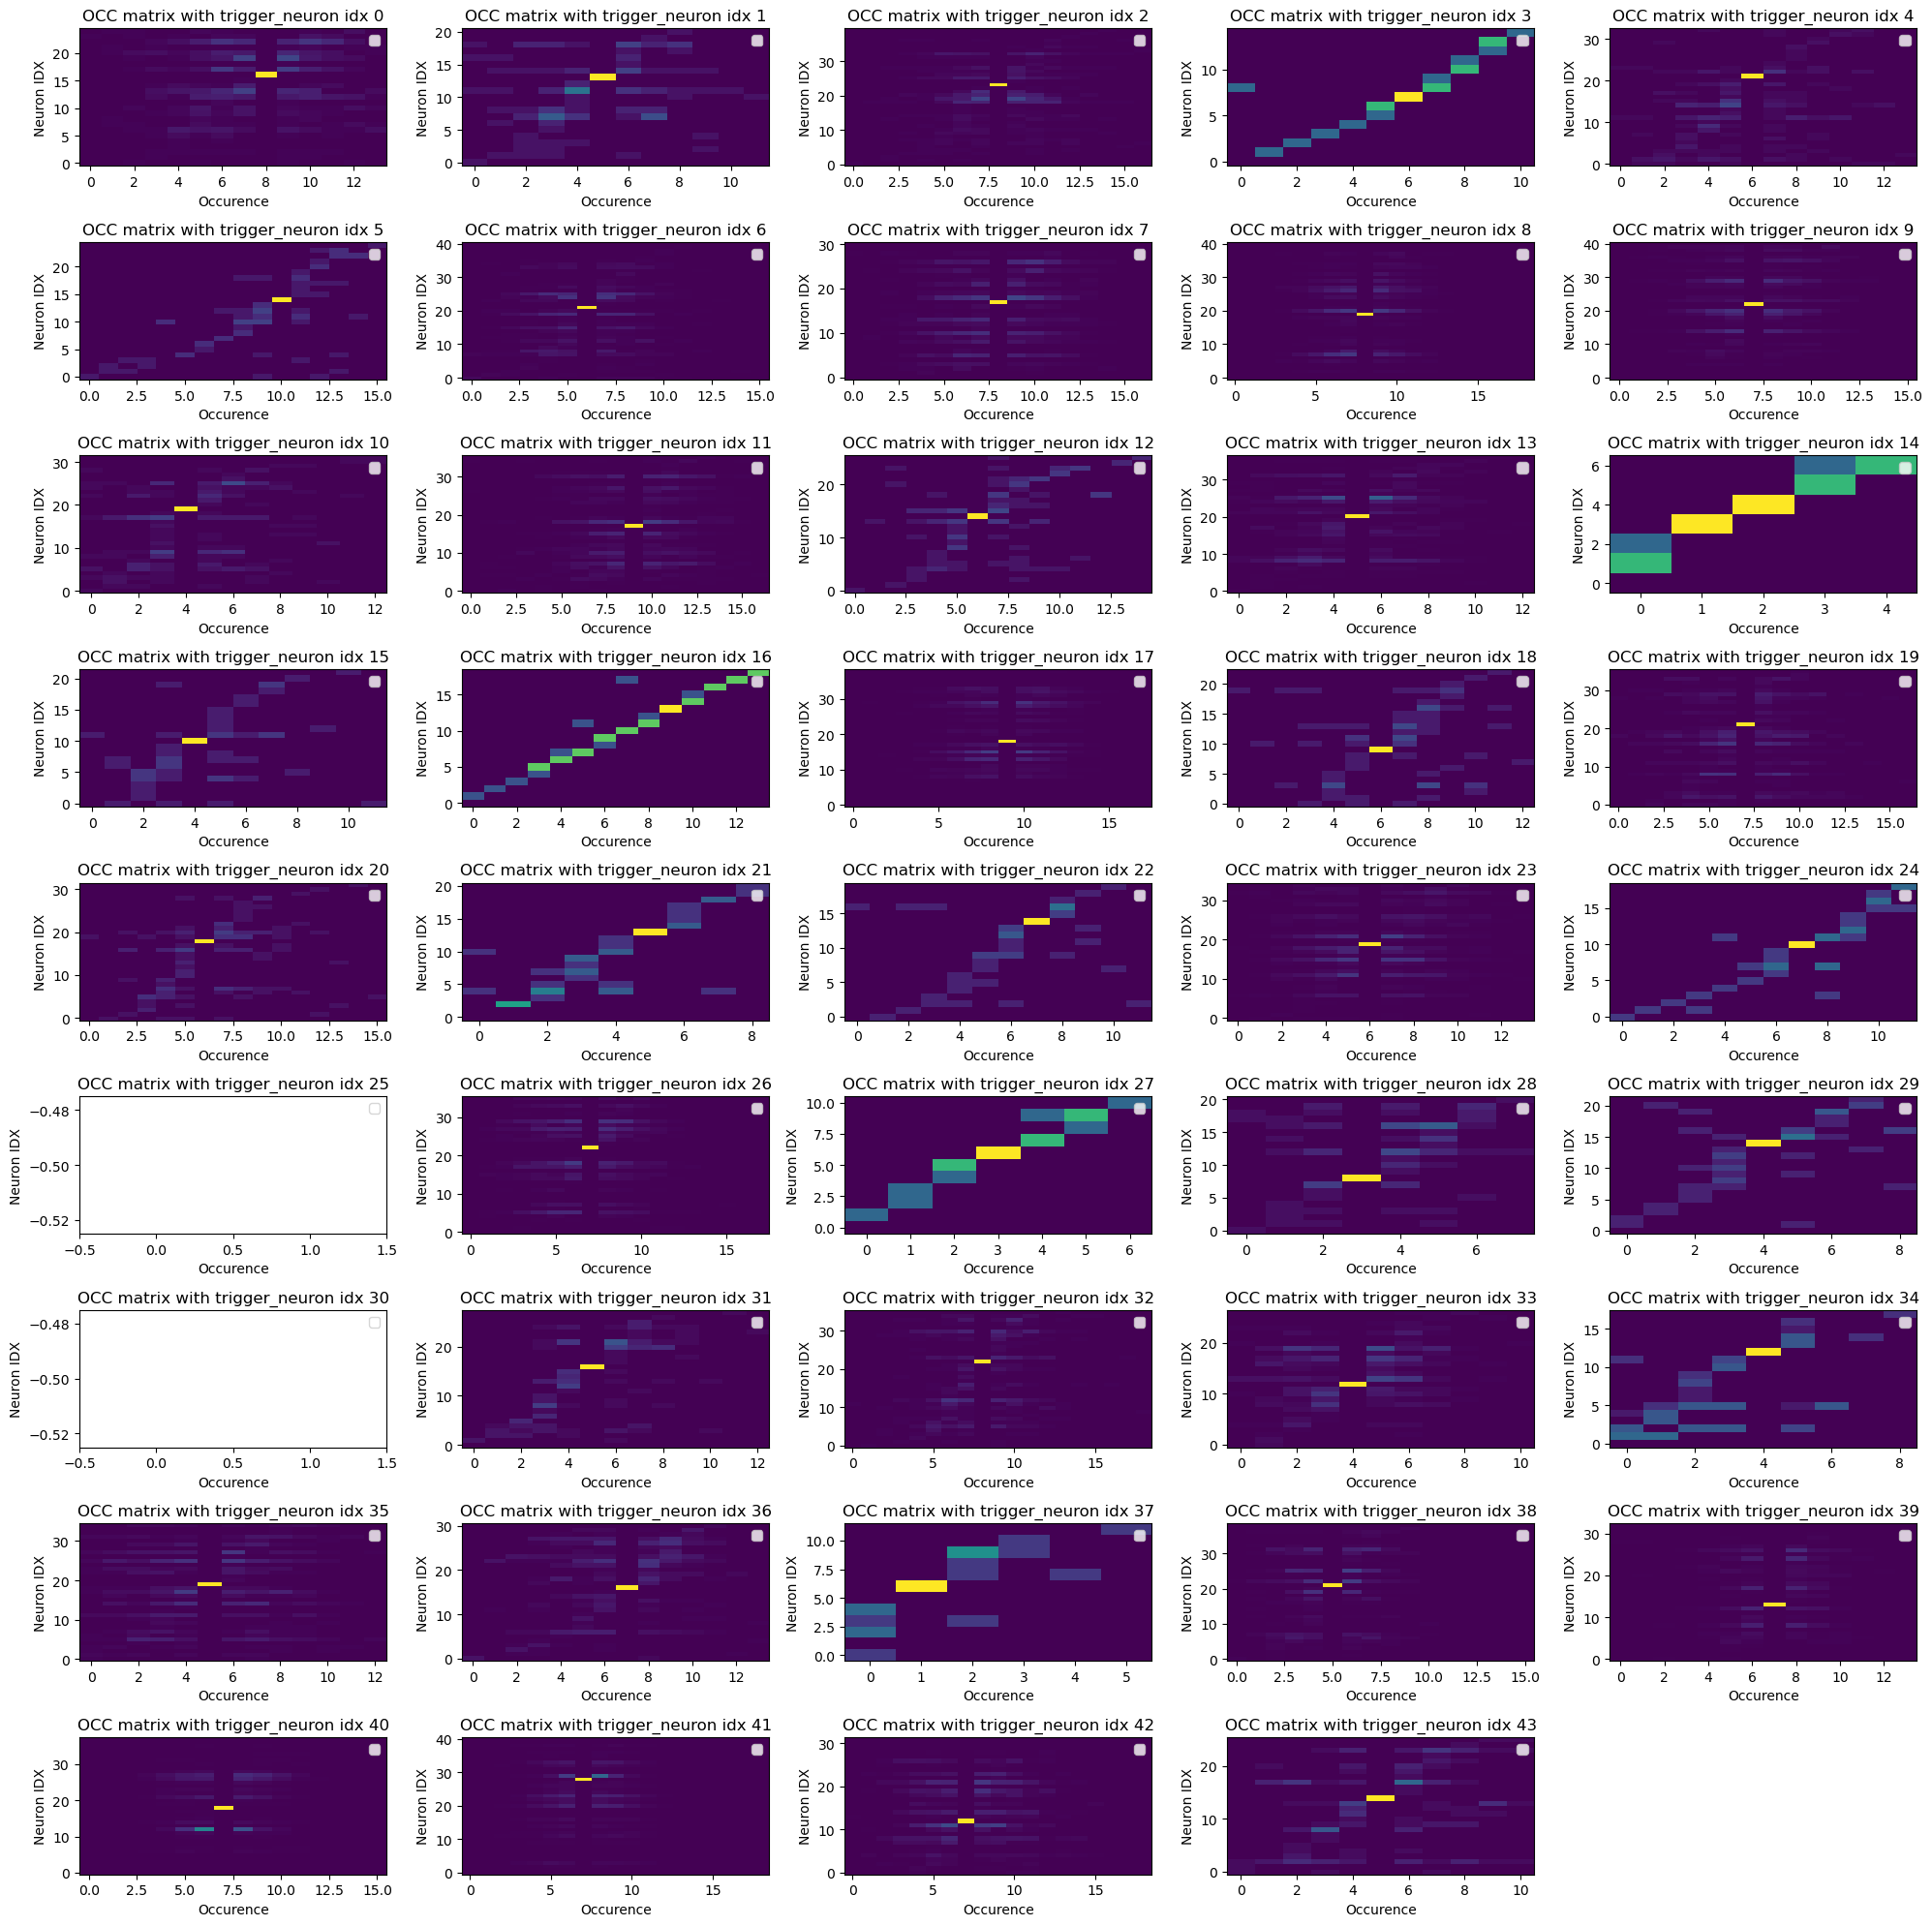

Rat11-20150330


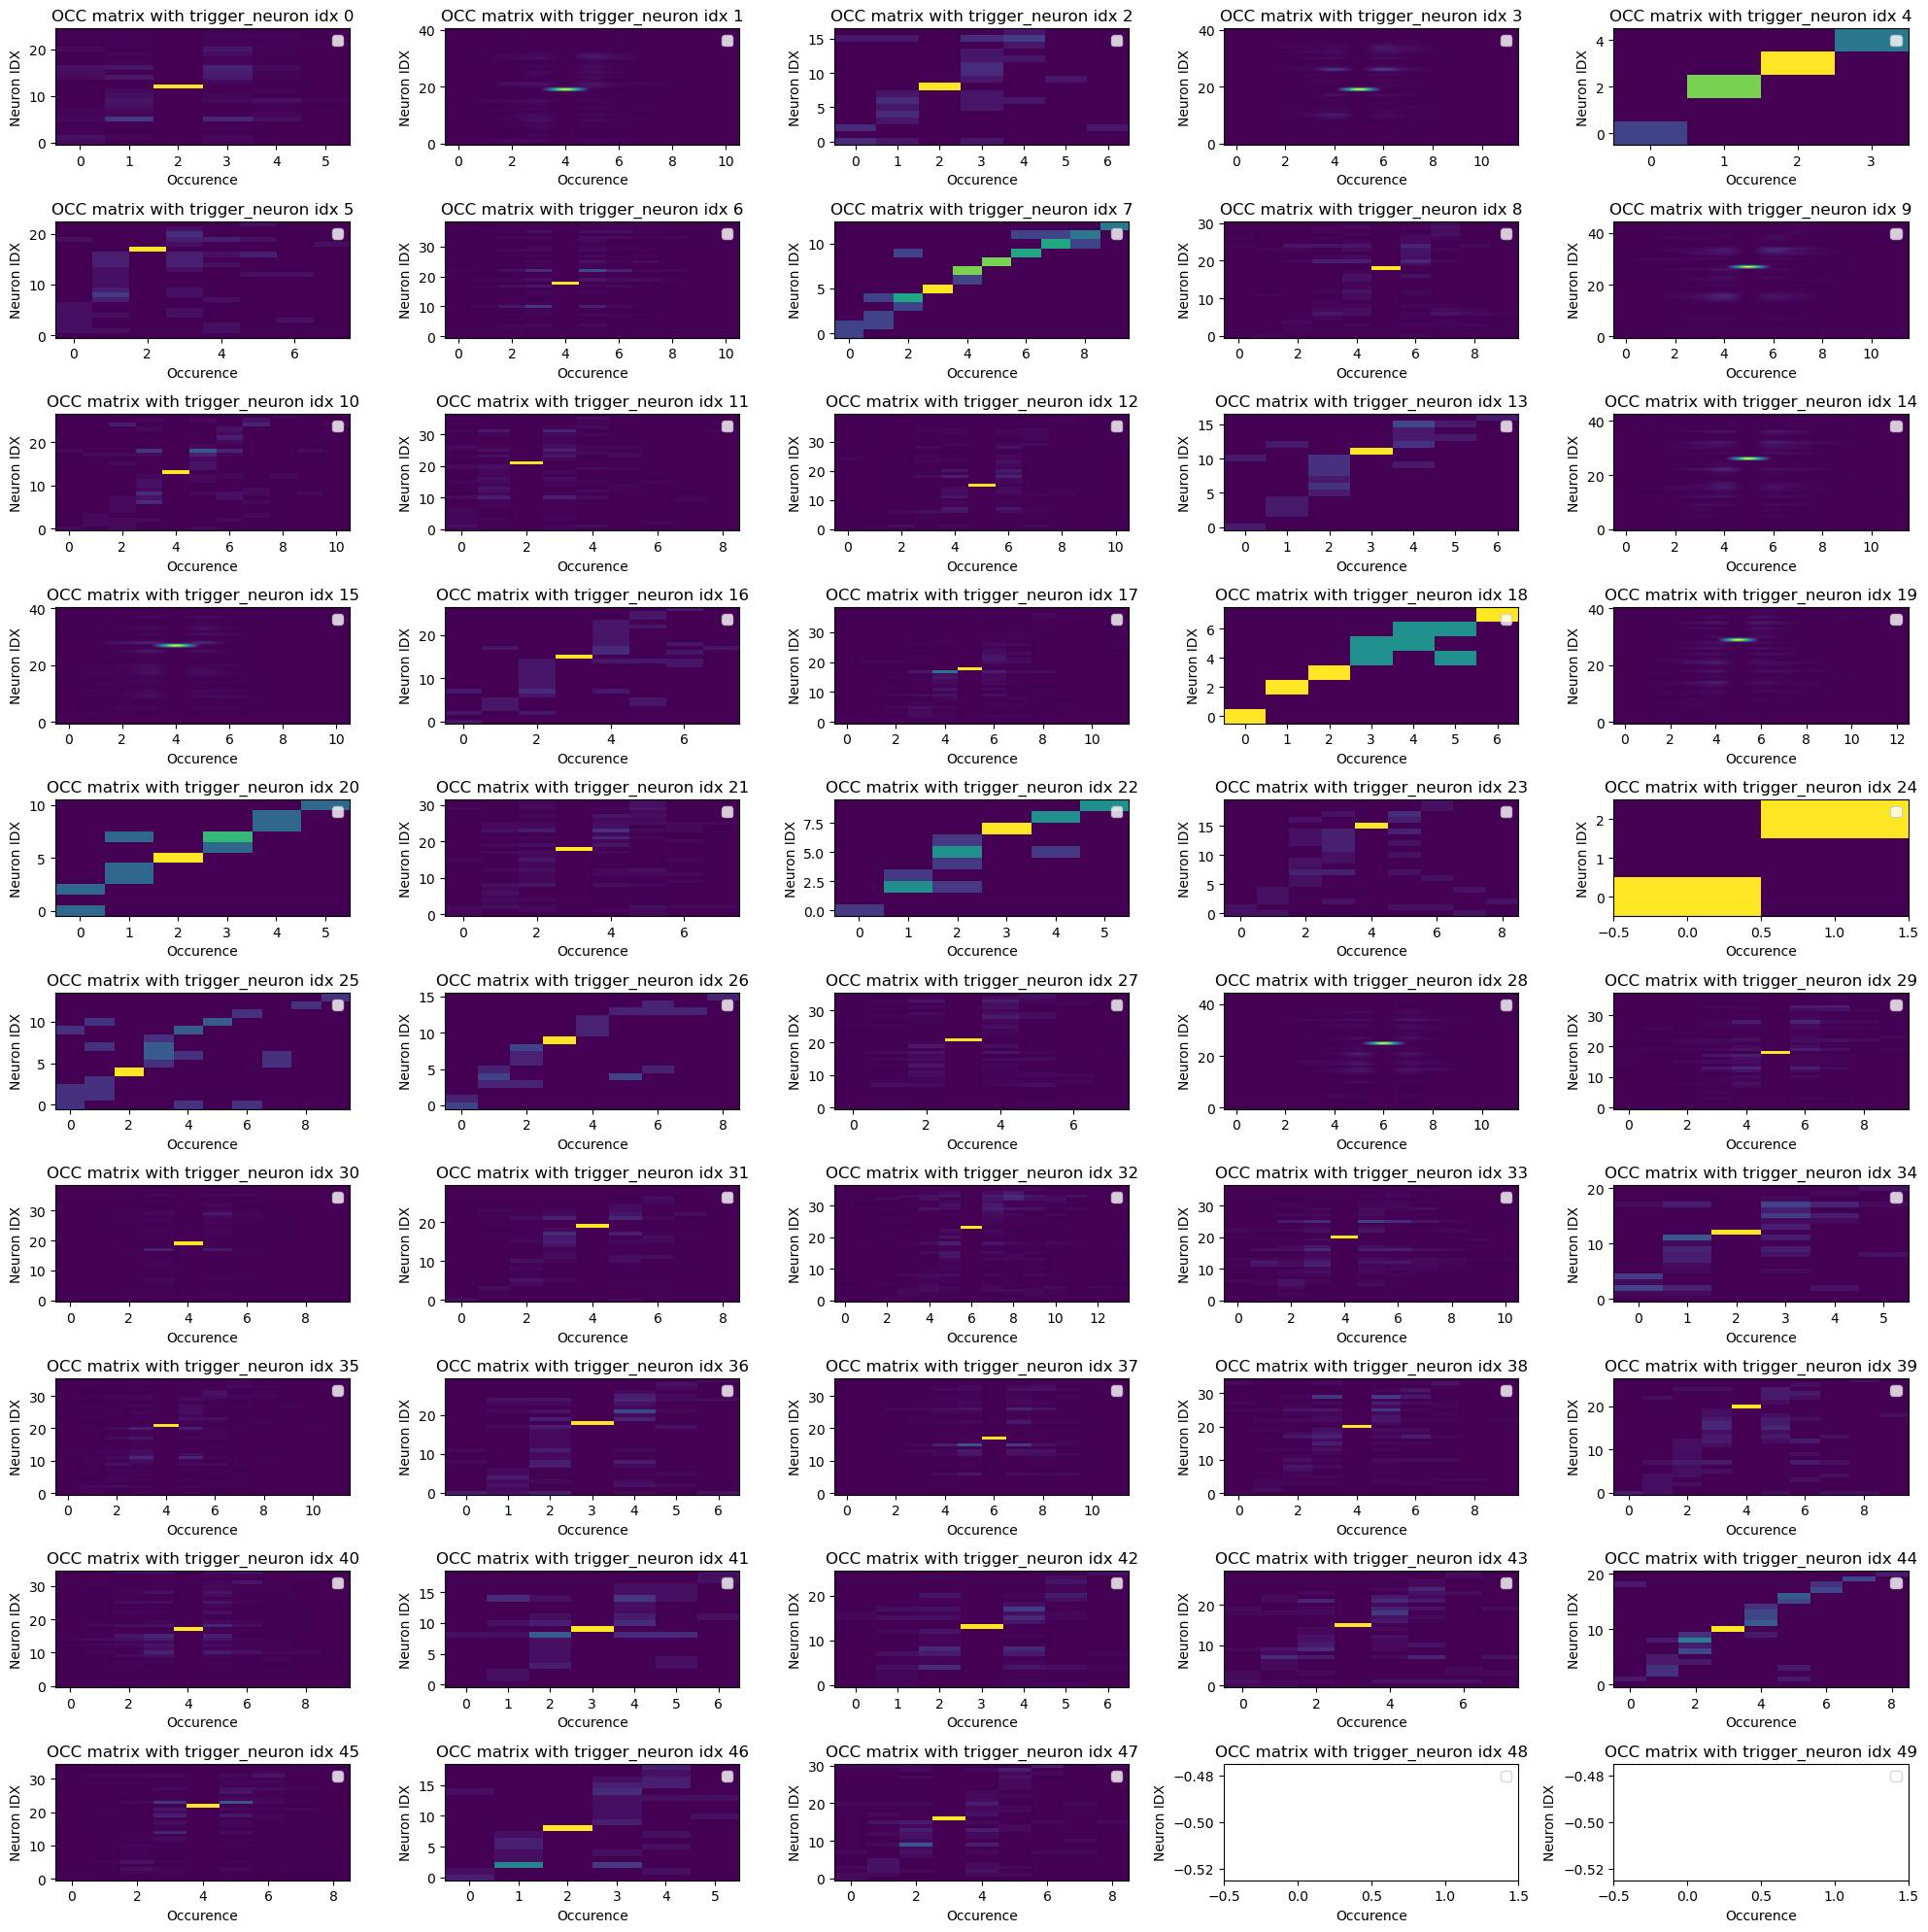

Rat11-20150331


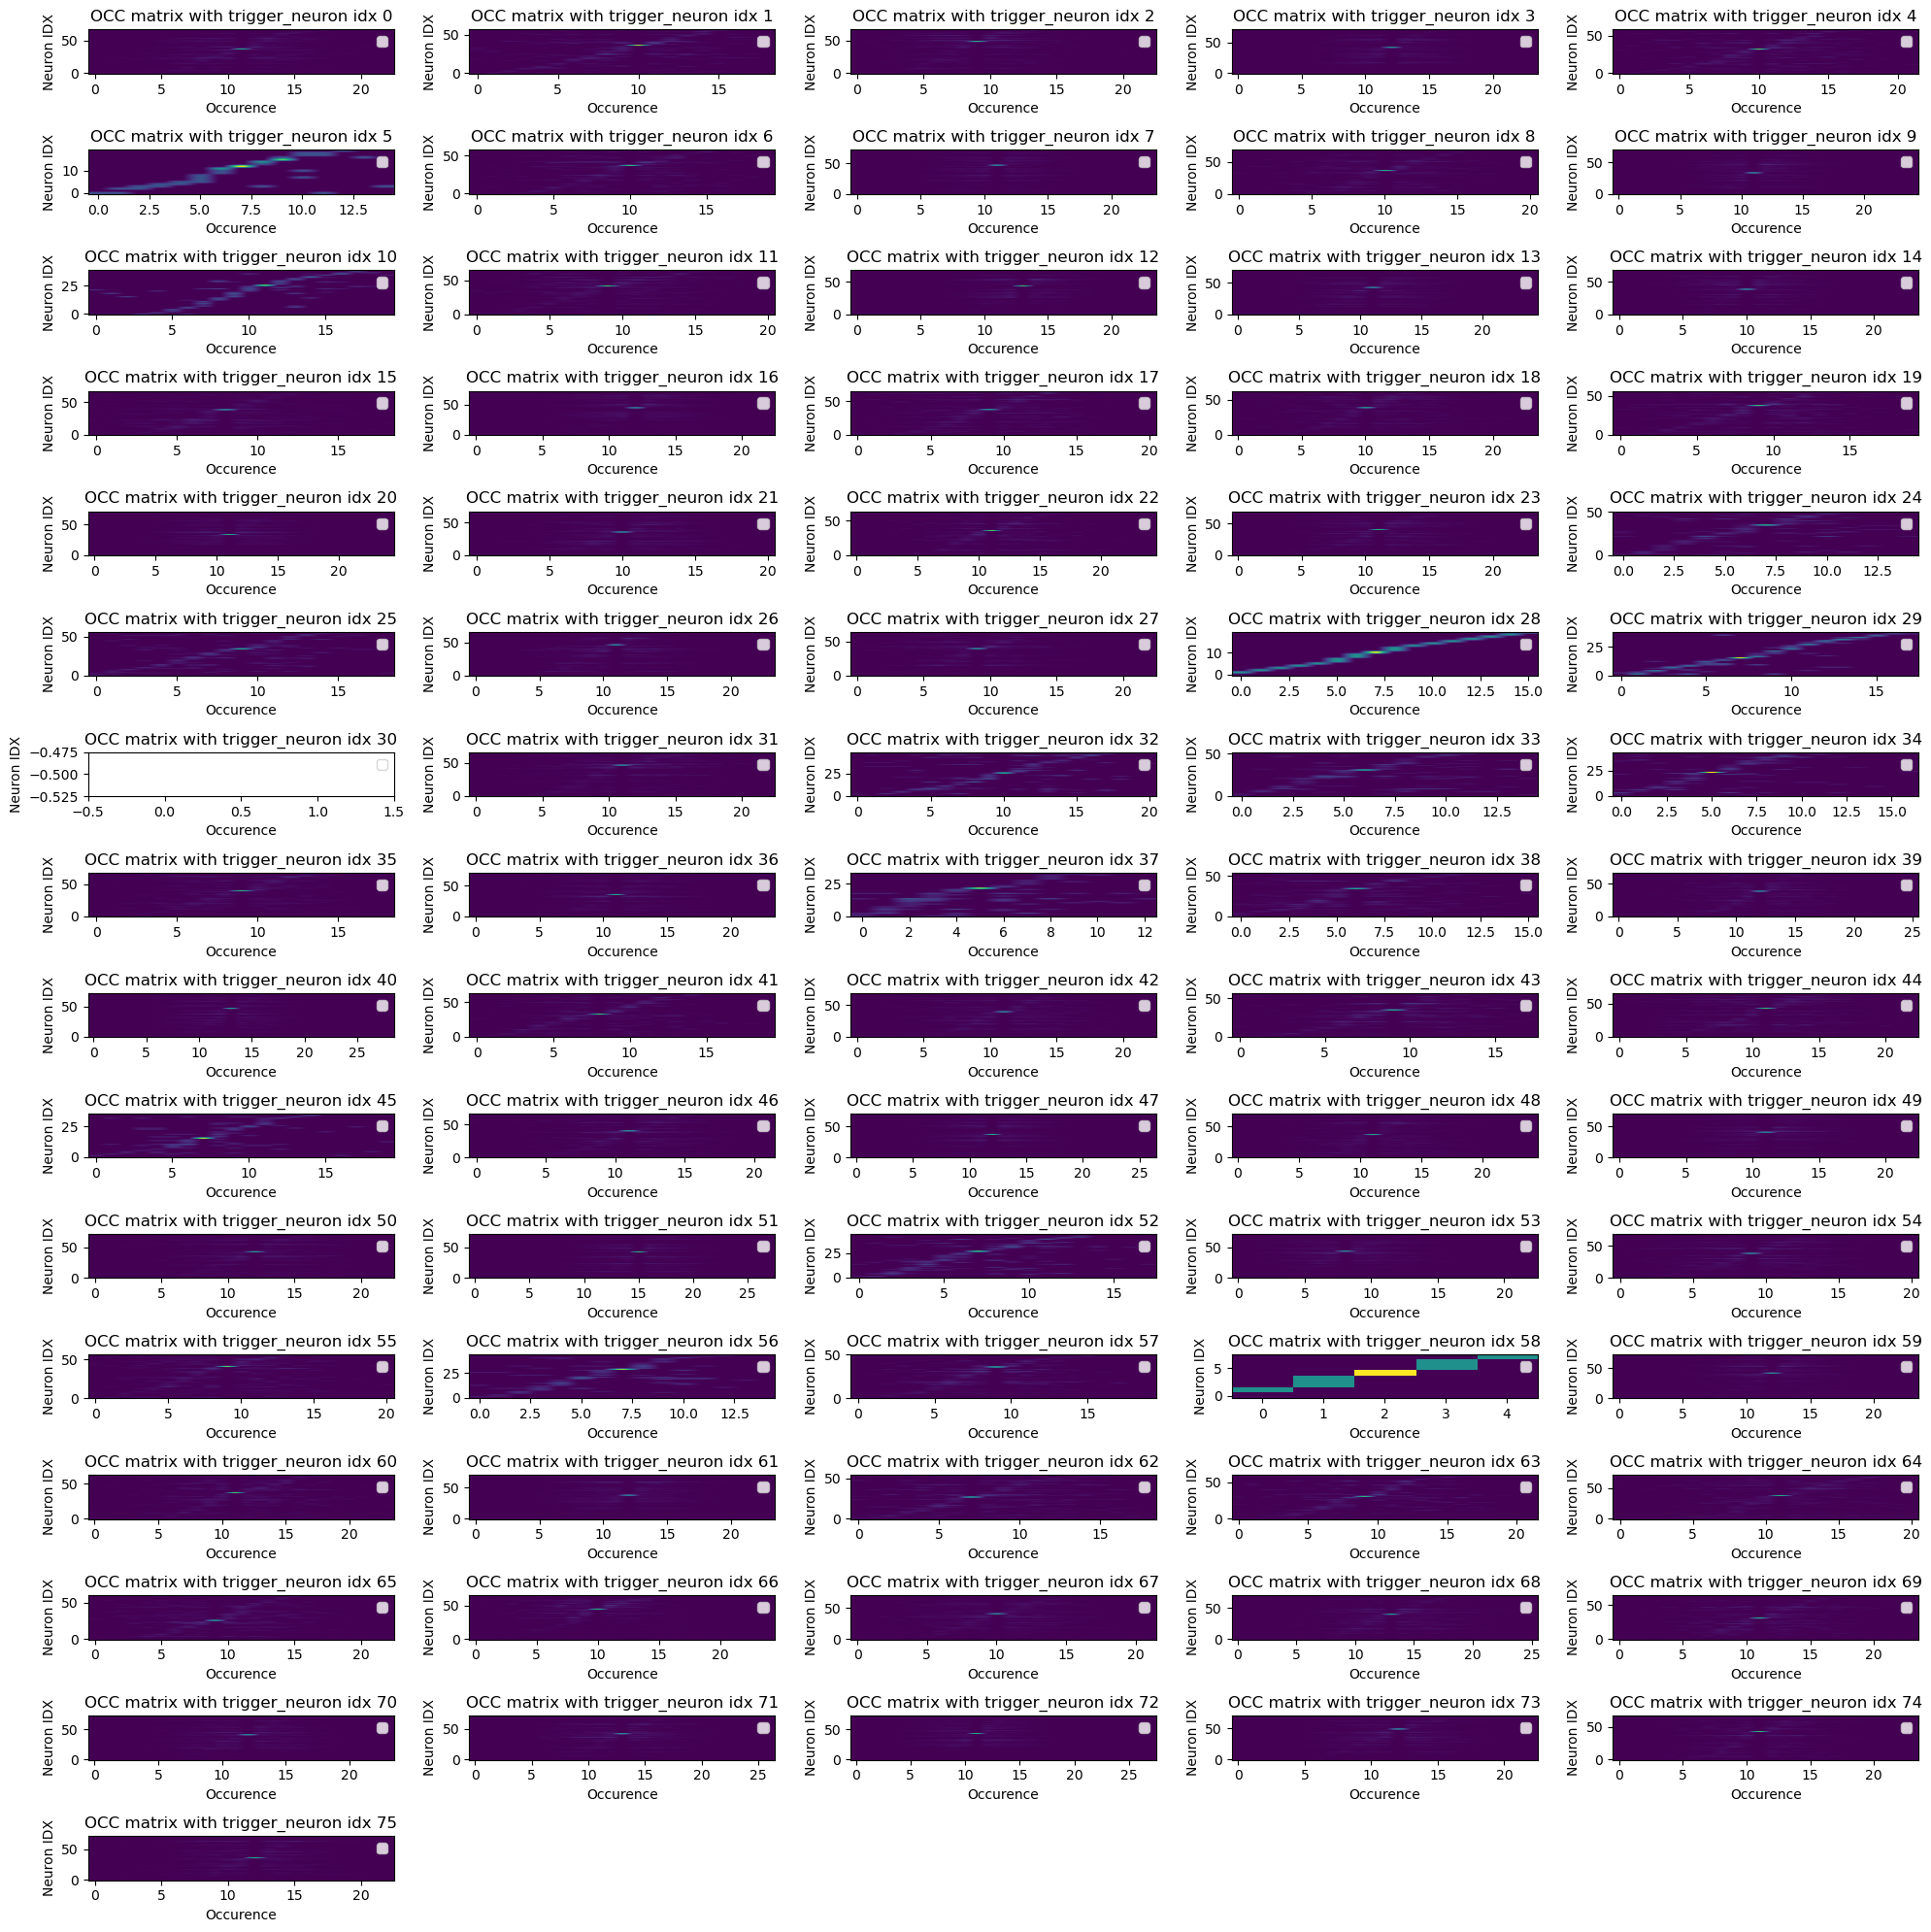

Rat11-20150401


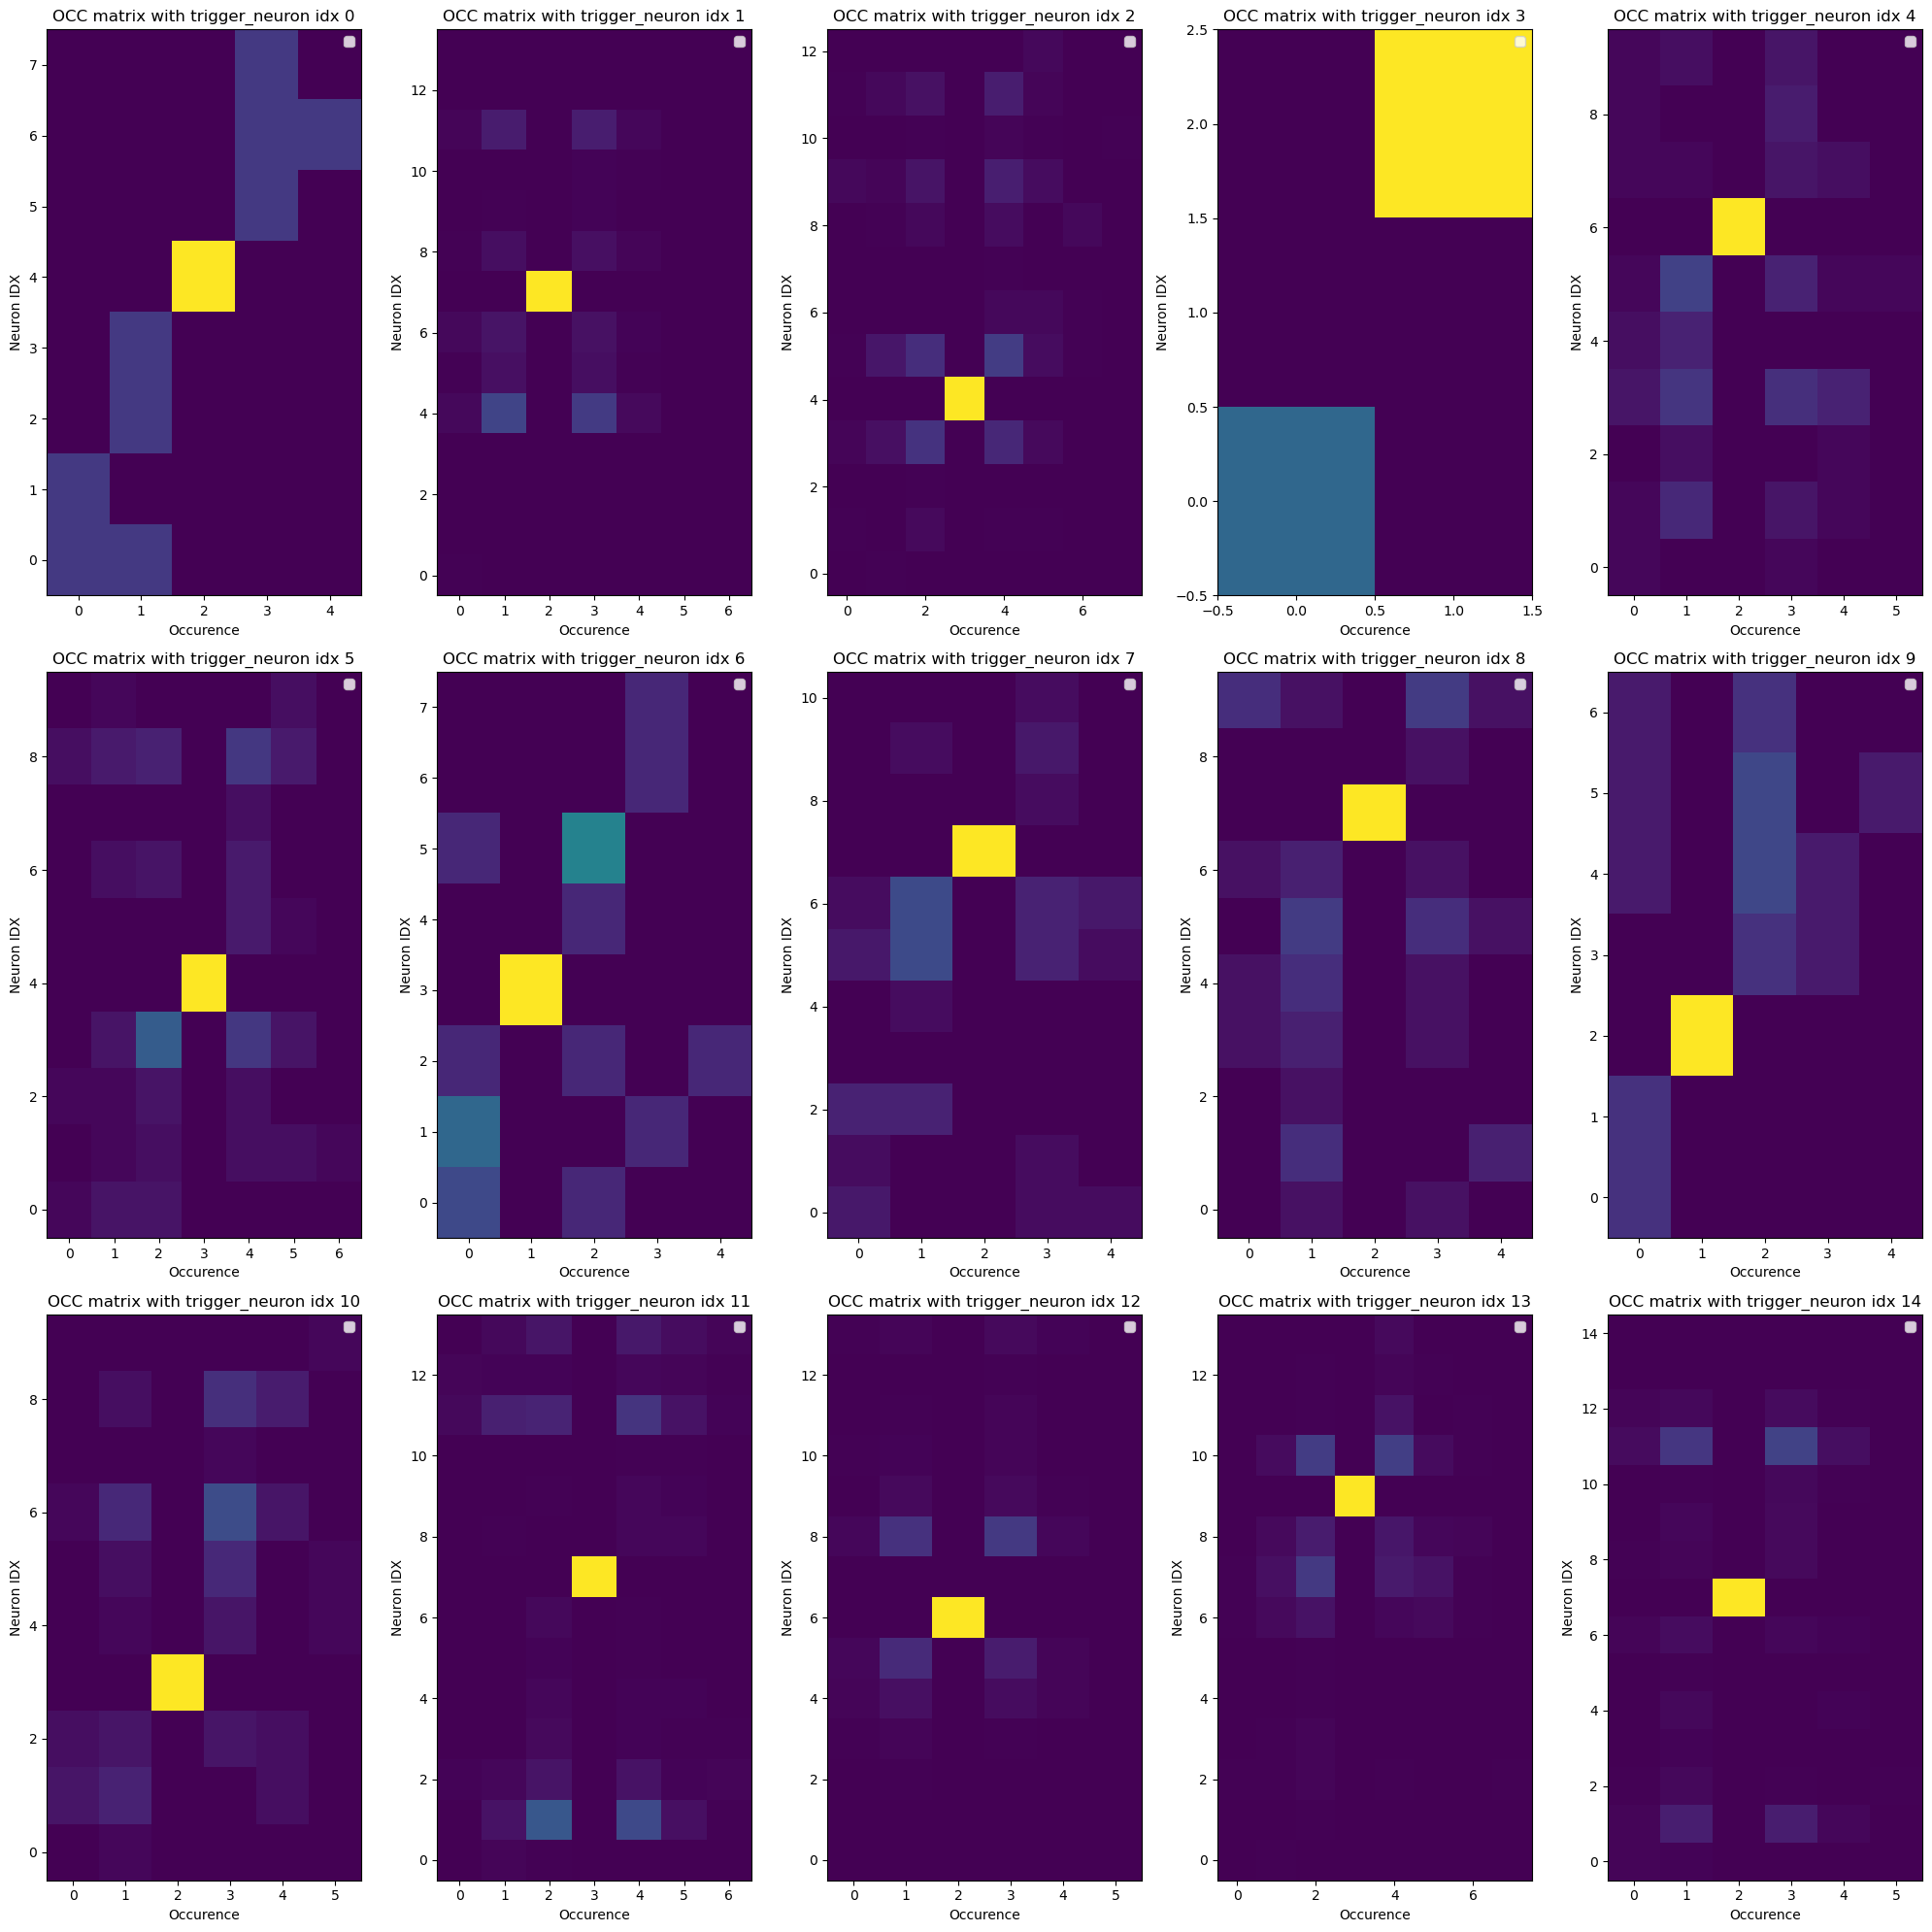

In [41]:
for session, matrices in results_per_session_rat11_complete.items():
    occ = matrices["occ"]
    mi_real = matrices["mi_real"]
    surrogates = matrices ["surrogates"]
    boundary = matrices ["boundary"]
    print(session)
    def plot_occs(occ_matrix, ax, neuron_idx):
        ax.imshow(sort_occ_matrix(occ_matrix)[0], aspect='auto', origin='lower')
        ax.set_xlabel('Occurence')
        ax.set_ylabel('Neuron IDX')
        ax.set_title(f'OCC matrix with trigger_neuron idx {neuron_idx}')
        ax.legend()

    num_plots = len(occ)
    cols = 5
    rows = (num_plots + cols - 1) // cols  # Ceiling division
    
    # Create subplots
    fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
    axes = axes.flatten()  # Flatten to make indexing easier
    
    # Loop through and plot
    for i in range(len(occ)):
        plot_occs(occ[i], axes[i], i)
    
    # Hide unused subplots
    for ax in axes[num_plots:]:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

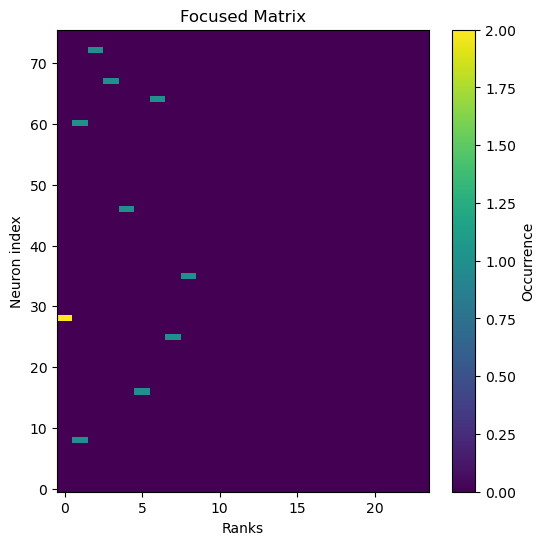

76


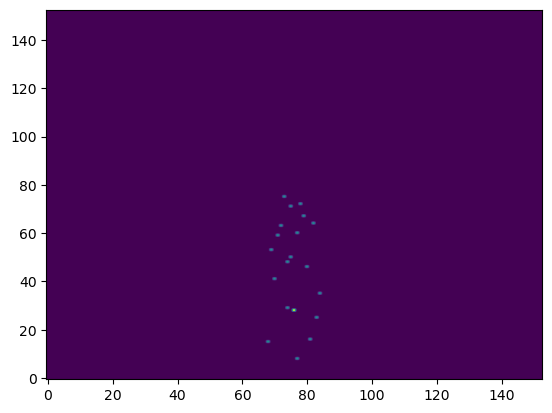

In [48]:
occ_test = results_per_session_rat11_middle_split['Rat11-20150331']["occ"]
row_start, row_end = 0, 76
col_start, col_end = 76, 100
focused_matrix = occ_test[28][row_start:row_end, col_start:col_end]
plt.figure(figsize=(6, 6))
plt.imshow(focused_matrix, aspect='auto', origin='lower', cmap='viridis')  # Adjust 'cmap' if needed
plt.colorbar(label='Occurrence')  # Add a colorbar for reference
plt.title("Focused Matrix")
plt.xlabel("Ranks")
plt.ylabel("Neuron index")
plt.show()



print(session_data_rat11_middle_split['Rat11-20150331']["n_neurons"])
plt.imshow(occ_test[28], aspect='auto', origin='lower')
plt.show()

In [47]:
def plot_ranks_distribution(mean_ranks, indices, session):
    plt.figure(figsize=(10, 4))
    y_position = 0  # All points share the same y-axis value
    
    plt.scatter(mean_ranks, [y_position] * len(mean_ranks), color='blue', zorder=2)
    
    # Annotate each point with its index
    for i, (x, idx) in enumerate(zip(mean_ranks, indices)):
        plt.text(x, y_position + 0.05, f"{idx}", fontsize=6, ha='center', color='black')
    
    plt.xlabel('Rank with Highest Occurrence', fontsize=12)
    plt.title(f'Highest Occurrence Ranks of Significant Neurons {session}', fontsize=14)
    plt.yticks([y_position], [''])  # Only one y-tick for alignment
    plt.axhline(y_position, color='gray', linestyle='--', zorder=1)  # Horizontal line for reference
    plt.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [30]:
%run Results_analysis_functions.ipynb

In [26]:
results_analysis_rat11_middle_split= {}

In [21]:
with open("rat11_results_middle_split", "rb") as pkl_file:
    results_per_session_rat11_middle_split = pickle.load(pkl_file)

In [31]:
results_analysis_rat11_middle_split_new = {}

In [36]:
for session, matrices in results_per_session_rat11_middle_split.items():
    if session == "Rat11-20150321" or session =="Rat11-20150325":
        continue
    occ = matrices["occ"]
    mi_real = matrices["mi_real"]
    surrogates = matrices ["surrogates"]
    boundary = matrices ["boundary"]
    test_matrix = session_data_rat11_middle_split[session]["test_matrix"]
    n_neurons = len(boundary)
    significant_neurons = get_significant_neurons(mi_real, boundary)
    print(session)

    if np.all(np.isnan(significant_neurons)):
        print(f'There are no significant neurons for session {session}')
        continue
       
    else: 
        rank_distribution, indices_sig_neur = get_significant_ranks(occ, significant_neurons)
        mean_ranks = np.nanmean(rank_distribution, axis=1)
        # plot_ranks_distribution(mean_ranks, indices_sig_neur, session)
        mean_ranks_sequence, neurons_idx_sequence = mean_ranks_to_seq(mean_ranks, indices_sig_neur)
    
        pattern_template_ = create_occ_pattern_template(occ, significant_neurons, neurons_idx_sequence)
        #slice it to the number of neurons
        pattern_template = pattern_template_[:n_neurons]
        values_first_half, time_points_first_half = get_weighted_values(test_matrix, pattern_template, window_size=120, step_size=30, first_half = True)
        values_second_half, time_points_second_half = get_weighted_values(test_matrix, pattern_template, window_size=120, step_size=30, first_half = False)
        
        results_analysis_rat11_middle_split_new[session] = {
        "pattern_template": pattern_template,
        "values_first_half": values_first_half,
        "time_points_first_half": time_points_first_half,
        "time_points_second_half": time_points_second_half,
        "values_second_half" : values_second_half,
        "significant_neurons" : significant_neurons
        }


Rat11-20150316
Test run 1: 99 empty spike matrices out of 345 total time points. Fraction of empty: 0.2870
Test run 2: 97 empty spike matrices out of 358 total time points. Fraction of empty: 0.2709
Test run 3: 113 empty spike matrices out of 367 total time points. Fraction of empty: 0.3079
Test run 4: 84 empty spike matrices out of 284 total time points. Fraction of empty: 0.2958
Test run 5: 53 empty spike matrices out of 303 total time points. Fraction of empty: 0.1749
Test run 6: 49 empty spike matrices out of 289 total time points. Fraction of empty: 0.1696
Test run 7: 35 empty spike matrices out of 357 total time points. Fraction of empty: 0.0980
Test run 8: 135 empty spike matrices out of 349 total time points. Fraction of empty: 0.3868
Test run 9: 29 empty spike matrices out of 240 total time points. Fraction of empty: 0.1208
Test run 10: 38 empty spike matrices out of 414 total time points. Fraction of empty: 0.0918
Test run 11: 28 empty spike matrices out of 429 total time poi

/var/folders/gx/7pdzybf540s07y1q49gzn5400000gn/T/ipykernel_76619/1160811379.py:19: RuntimeWarning: Mean of empty slice
  mean_ranks = np.nanmean(rank_distribution, axis=1)


Test run 1: 145 empty spike matrices out of 437 total time points. Fraction of empty: 0.3318
Test run 2: 131 empty spike matrices out of 572 total time points. Fraction of empty: 0.2290
Test run 3: 114 empty spike matrices out of 358 total time points. Fraction of empty: 0.3184
Test run 4: 46 empty spike matrices out of 356 total time points. Fraction of empty: 0.1292
Test run 5: 62 empty spike matrices out of 363 total time points. Fraction of empty: 0.1708
Test run 6: 43 empty spike matrices out of 300 total time points. Fraction of empty: 0.1433
Test run 7: 67 empty spike matrices out of 310 total time points. Fraction of empty: 0.2161
Test run 8: 154 empty spike matrices out of 492 total time points. Fraction of empty: 0.3130
Test run 9: 44 empty spike matrices out of 334 total time points. Fraction of empty: 0.1317
Test run 10: 38 empty spike matrices out of 308 total time points. Fraction of empty: 0.1234
Test run 11: 22 empty spike matrices out of 238 total time points. Fraction

In [38]:
def plot_paired_scatter_no_jitter(first_half, second_half, colors=("blue", "red"),
                                  labels=("First Half", "Second Half"), title="Paired Data Scatter Plot"):
    """
    Plots a scatter plot for paired data without jittered positions or connecting lines.

    Parameters:
    - first_half (array-like): Values for the first half.
    - second_half (array-like): Values for the second half.
    - colors (tuple): Colors for the first and second halves (e.g., ("blue", "red")).
    - labels (tuple): Labels for the x-axis categories (e.g., ("First Half", "Second Half")).
    - title (str): Title of the plot.

    Returns:
    - None
    """
    # Convert inputs to numpy arrays
    first_half = np.array(first_half)
    second_half = np.array(second_half)

    # Create scatter plot
    plt.scatter([1] * len(first_half), first_half, color=colors[0], label=labels[0], alpha=0.7)
    plt.scatter([2] * len(second_half), second_half, color=colors[1], label=labels[1], alpha=0.7)

    # Customize the plot
    plt.xticks([1, 2], labels)
    plt.ylabel("Values")
    plt.title(title)

def plot_mean_run(values_first_half, time_points_first_half,
                  values_second_half, time_points_second_half):
    # Compute mean values across all runs
    mean_first_half = np.nanmean(values_first_half, axis=0)
    mean_second_half = np.nanmean(values_second_half, axis=0)

    # Assume time points are the same for all runs; use the first one
    mean_time_first_half = time_points_first_half[0]
    mean_time_second_half = time_points_second_half[0]

    plt.figure(figsize=(10, 6))

    # Plot mean values
    plt.plot(mean_time_first_half, mean_first_half, color='blue', linewidth=1.5, label='First Half (Mean)')
    plt.plot(mean_time_second_half, mean_second_half, color='red', linewidth=1.5, label='Second Half (Mean)')

    plt.xlabel('Time')
    plt.ylabel('Values')
    plt.title('Mean Projection Across All Runs')
    plt.grid(True)
    plt.legend()

### Example session with high number of neurons

In [44]:
session_id_outlier = 'Rat11-20150330'
values_first_half_high = results_analysis_rat11_middle_split_new[session_id_outlier]["values_first_half"]
time_points_first_half_high = results_analysis_rat11_middle_split_new[session_id_outlier]["time_points_first_half"]
values_second_half_high = results_analysis_rat11_middle_split_new[session_id_outlier]["values_second_half"]
time_points_second_half_high = results_analysis_rat11_middle_split_new[session_id_outlier]["time_points_second_half"]

In [62]:
mean_first_half_value_high, mean_second_half_value_high = np.nanmean(values_first_half_high, axis=1), np.nanmean(values_second_half_high, axis=1) 
overall_mean_first_half_value_high, overall_mean_second_half_value_og = np.nanmean(mean_first_half_value_high), np.nanmean(mean_second_half_value_high)

## Results across sessions

In [72]:
rat11_across_sessions = {}
for session, matrices in results_analysis_rat11_middle_split.items():
    values_first_half = matrices["values_first_half"]
    values_second_half = matrices["values_second_half"]
    signif_neurons = matrices["significant_neurons"]
    rank_distribution, indices_sig_neur = get_significant_ranks(occ, significant_neurons)
    number_signif = len (indices_sig_neur)
    ratio_signif = number_signif/len(signif_neurons)
    
    # plot_means_first_second_half(values_first_half, values_second_half)
    mean_first_half_value, mean_second_half_value = np.nanmean(values_first_half, axis=1), np.nanmean(values_second_half, axis=1) 
    mean_first_half =  np.nanmean(mean_first_half_value)
    mean_second_half =  np.nanmean(mean_second_half_value)
    difference = mean_first_half - mean_second_half
    
    stat, p_value = wilcoxon(mean_first_half_value, mean_second_half_value)

    rat11_across_sessions[session] = {
    "ratio_signif_neurons": ratio_signif,
    "significance_neurons": signif_neurons,
    "indices_significant": indices_sig_neur,
    "means_first_middle": mean_first_half,
    "means_second_middle": mean_second_half,
    "difference": difference,
    "mean_first_half_value": mean_first_half_value,
    "mean_second_half_value": mean_second_half_value,
    "wilcoxon_stat_in_session": stat,
    "wilcoxon_p_in_session": p_value
    }

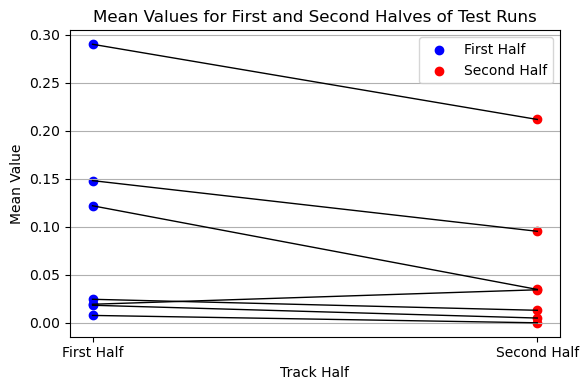

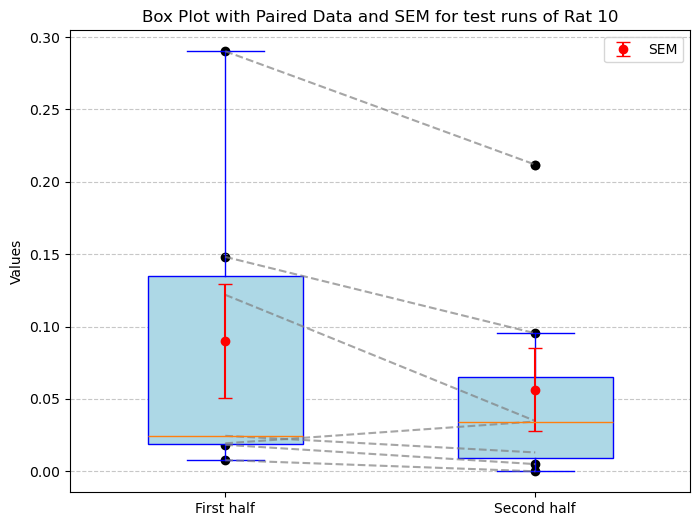

Wilcoxon test statistic: 4.0, p-value: 0.109375


In [33]:
plot_means_test_runs_means(means_first_middle, means_second_middle)
boxplot_sem_means(means_first_middle, means_second_middle)
paired_test_mean(means_first_middle, means_second_middle)

In [36]:
import pickle
# Save to file
with open("rat11_means_middle_first.pkl", "wb") as pkl_file:
    pickle.dump(means_first_middle, pkl_file)

with open("rat11_means_middle_second.pkl", "wb") as pkl_file:
    pickle.dump(means_second_middle, pkl_file)

[0.12189323271992678, 0.018276311217605912, 0.29012538990862746, 0.02448775907466129, 0.14809324595901413, 0.007682037894197248, 0.01931139939394768]


In [73]:
with open("rat11_results_across_sessions", "wb") as pkl_file:
    pickle.dump(rat11_across_sessions, pkl_file)

In [74]:
with open("rat11_results_third_split ", "wb") as pkl_file:
    pickle.dump(results_per_session_rat11_third_split, pkl_file)

with open("rat11_results_middle_split", "wb") as pkl_file:
    pickle.dump(results_per_session_rat11_middle_split, pkl_file)

In [19]:
import pickle
with open("rat11_sesion_data_middle_split", "wb") as pkl_file:
    pickle.dump(session_data_rat11_middle_split, pkl_file)